In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
import xgboost as xgb

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###Get train test week

In [ ]:
train = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/train_12-19_standardized.csv", index_col=0)
test = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/test_20-22_standardized.csv", index_col=0)
test.tail()

,Department,Date,Year,Quantity Seized (kg),Log Quantity Seized (kg),Binned Quantity,Percent Population in Urban Areas,HDI,GDI,Mean International Wealth Index,...,Educational Index,Mean Years Schooling,Log Gross National Income Per Capita in 1000 USD,Life Expectancy,Population Density,Number of Corruption Cases,Percent of Total Corruption Cases for That Year,Number of Homicides that Year,Gini Coefficient,% Poorest Household (IWI under 30)
36163,Sucre,2022-12-31,2022,0.0,0.0,0 kg,-0.621055,-0.037034,0.447425,1.082932,...,NaN,0.056048,0.113795,-0.617671,-0.224696,-0.094842,2.054084,-0.339157,-1.222036,-0.613357
36164,Tolima,2022-12-31,2022,0.0,0.0,0 kg,0.054799,0.046110,1.225996,0.565045,...,NaN,0.174398,0.359412,-1.066436,-0.267381,-0.389053,0.670721,-0.068491,-1.222036,-0.613357
36165,Valle del Cauca,2022-12-31,2022,0.0,0.0,0 kg,1.191949,1.293273,-0.053085,1.824045,...,NaN,2.057053,1.394511,-0.765435,-0.067988,-0.683264,-0.712641,3.061082,-1.222036,-0.613357
36166,Vaupés,2022-12-31,2022,0.0,0.0,0 kg,-3.370598,-2.891652,-3.667878,-4.569173,...,NaN,-0.633164,-3.228348,-4.289887,-0.334189,-0.683264,-0.712641,-0.670722,-1.222036,-0.613357
36167,Vichada,2022-12-31,2022,0.0,0.0,0 kg,1.728341,0.267828,0.280588,1.779399,...,NaN,1.099316,0.607953,-0.978872,-0.333774,-0.683264,-0.712641,-0.648731,-1.222036,-0.613357


In [ ]:
#@CITATION: CODE ADAPTED FROM CHAT GPT
combined_df = pd.concat([train, test], ignore_index=True)

# Optional: Reset index if needed
combined_df.reset_index(drop=True, inplace=True)



combined_df['Date'] = pd.to_datetime(combined_df['Date'])

# Sort by date in case it's not sorted
combined_df = combined_df.sort_values(by='Date')

# Calculate the "week number" from the start of your dataset
combined_df['week_number'] = (combined_df['Date'] - combined_df['Date'].min()).dt.days // 7

# Now you can group by department and week_number for aggregation
week_combined_df = combined_df.sort_values(by=['Department', 'week_number'])
week_combined_df['week_number'] = week_combined_df['week_number'].astype(int)
week_combined_df.tail()

,Department,Date,Year,Quantity Seized (kg),Log Quantity Seized (kg),Binned Quantity,Percent Population in Urban Areas,HDI,GDI,Mean International Wealth Index,...,Mean Years Schooling,Log Gross National Income Per Capita in 1000 USD,Life Expectancy,Population Density,Number of Corruption Cases,Percent of Total Corruption Cases for That Year,Number of Homicides that Year,Gini Coefficient,% Poorest Household (IWI under 30),week_number
132461,Vichada,2022-12-27,2022,0.0,0.0,0 kg,1.728341,0.267828,0.280588,1.779399,...,1.099316,0.607953,-0.978872,-0.333774,-0.683264,-0.712641,-0.648731,-1.222036,-0.613357,573
132494,Vichada,2022-12-28,2022,0.0,0.0,0 kg,1.728341,0.267828,0.280588,1.779399,...,1.099316,0.607953,-0.978872,-0.333774,-0.683264,-0.712641,-0.648731,-1.222036,-0.613357,573
132527,Vichada,2022-12-29,2022,0.0,0.0,0 kg,1.728341,0.267828,0.280588,1.779399,...,1.099316,0.607953,-0.978872,-0.333774,-0.683264,-0.712641,-0.648731,-1.222036,-0.613357,573
132560,Vichada,2022-12-30,2022,0.0,0.0,0 kg,1.728341,0.267828,0.280588,1.779399,...,1.099316,0.607953,-0.978872,-0.333774,-0.683264,-0.712641,-0.648731,-1.222036,-0.613357,573
132593,Vichada,2022-12-31,2022,0.0,0.0,0 kg,1.728341,0.267828,0.280588,1.779399,...,1.099316,0.607953,-0.978872,-0.333774,-0.683264,-0.712641,-0.648731,-1.222036,-0.613357,573


In [ ]:

columns_to_aggregate = ['Date',
       'Percent Population in Urban Areas', 'HDI', 'GDI',
       'Mean International Wealth Index', 'Infant Deaths per 1000 Live Births',
       'Income Index', 'Health Index', 'Educational Index',
       'Mean Years Schooling',
       'Log Gross National Income Per Capita in 1000 USD', 'Life Expectancy',
       'Population Density', 'Number of Corruption Cases',
       'Percent of Total Corruption Cases for That Year',
       'Number of Homicides that Year', 'Gini Coefficient',
       '% Poorest Household (IWI under 30)']

week_combined_df  = (week_combined_df.groupby(['week_number', 'Department']).agg({'Quantity Seized (kg)': 'sum', 'Log Quantity Seized (kg)': 'sum',
                        **{col: 'first' for col in columns_to_aggregate}})
                  .reset_index())
week_combined_df.drop(columns=['Log Quantity Seized (kg)'], inplace=True)
week_combined_df['Log Quantity Seized (kg)'] = np.log(week_combined_df['Quantity Seized (kg)'])

week_combined_df['Log Quantity Seized (kg)'] = week_combined_df['Log Quantity Seized (kg)'].clip(lower=0)
week_combined_df.head()


/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,week_number,Department,Quantity Seized (kg),Date,Percent Population in Urban Areas,HDI,GDI,Mean International Wealth Index,Infant Deaths per 1000 Live Births,Income Index,...,Mean Years Schooling,Log Gross National Income Per Capita in 1000 USD,Life Expectancy,Population Density,Number of Corruption Cases,Percent of Total Corruption Cases for That Year,Number of Homicides that Year,Gini Coefficient,% Poorest Household (IWI under 30),Log Quantity Seized (kg)
0,0,Amazonas,0.000,2012-01-01,-1.613379,-1.644489,-2.221961,-1.720798,0.643927,-1.740106,...,-0.531722,-1.745875,-1.340074,-0.334521,-0.389053,-0.260388,-0.662264,0.103041,1.095493,0.000000
1,0,Antioquia,48.185,2012-01-01,0.462456,0.295543,0.280588,0.359676,-0.366227,0.544036,...,0.058038,0.552396,0.164933,-0.334521,0.199369,0.644118,4.536211,0.103041,1.095493,3.875048
2,0,Arauca,0.000,2012-01-01,0.505368,-0.203322,0.614262,0.073946,-0.599340,0.234322,...,-0.502880,0.230755,0.531607,-0.220003,-0.683264,-0.712641,-0.416973,0.103041,1.095493,0.000000
3,0,"Archipiélago de San Andrés, Providencia y Sant...",0.000,2012-01-01,-0.047116,0.905267,0.113752,0.440038,-0.356514,0.640822,...,2.019261,0.637193,0.110205,-0.324833,-0.683264,-0.712641,-0.652114,0.103041,1.095493,0.000000
4,0,Atlántico,0.606,2012-01-01,1.438689,0.461831,-0.497983,0.243598,0.061146,0.427894,...,0.896431,0.426664,-0.316669,1.122186,-0.094842,0.191865,0.249541,0.103041,1.095493,0.000000


In [ ]:
week_combined_df = week_combined_df.sort_values(by=['Department', 'week_number'])

border_depts = ['Nariño', 'Putumayo', 'Amazonas', 'Vaupés', 'Guainia', 'Vichada', 'Arauca', 'Norte de Santander', 'Cesar', 'La Guajira', 'Choco' ]
week_combined_df['Border_Department'] = week_combined_df['Department'].apply(lambda x: 1 if x in border_depts else 0)

ocean_depts = ['Nariño', 'Cauca', 'Valle del Cauca', 'Chocó', 'Antioquia', 'Córdoba', 'Sucre', 'Bolívar', 'Atlántico', 'Magdalena', 'La Guajira']


week_combined_df['Ocean_department'] = week_combined_df['Department'].apply(lambda x: 1 if x in border_depts else 0)


In [ ]:
week_combined_df.head()

,week_number,Department,Quantity Seized (kg),Date,Percent Population in Urban Areas,HDI,GDI,Mean International Wealth Index,Infant Deaths per 1000 Live Births,Income Index,...,Life Expectancy,Population Density,Number of Corruption Cases,Percent of Total Corruption Cases for That Year,Number of Homicides that Year,Gini Coefficient,% Poorest Household (IWI under 30),Log Quantity Seized (kg),Border_Department,Ocean_department
0,0,Amazonas,0.000,2012-01-01,-1.613379,-1.644489,-2.221961,-1.720798,0.643927,-1.740106,...,-1.340074,-0.334521,-0.389053,-0.260388,-0.662264,0.103041,1.095493,-inf,1,1
33,1,Amazonas,0.000,2012-01-08,-1.613379,-1.644489,-2.221961,-1.720798,0.643927,-1.740106,...,-1.340074,-0.334521,-0.389053,-0.260388,-0.662264,0.103041,1.095493,-inf,1,1
66,2,Amazonas,0.000,2012-01-15,-1.613379,-1.644489,-2.221961,-1.720798,0.643927,-1.740106,...,-1.340074,-0.334521,-0.389053,-0.260388,-0.662264,-0.338652,-0.415872,-inf,1,1
99,3,Amazonas,0.149,2012-01-22,-1.613379,-1.644489,-2.221961,-1.720798,0.643927,-1.740106,...,-1.340074,-0.334521,-0.389053,-0.260388,-0.662264,-0.338652,-0.415872,-1.903809,1,1
132,4,Amazonas,0.000,2012-01-29,-1.613379,-1.644489,-2.221961,-1.720798,0.643927,-1.740106,...,-1.340074,-0.334521,-0.389053,-0.260388,-0.662264,-0.338652,-0.490433,-inf,1,1


In [ ]:
week_combined_df.to_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/combined_weekly_12-22_standardized.csv")

###Adding border / ocean features

In [ ]:
train = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/train_monthly_12-19_normalized.csv", index_col=0)
test= pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/test_monthly_20-22_normalized.csv", index_col=0)

border_depts = ['Nariño', 'Putumayo', 'Amazonas', 'Vaupés', 'Guainia', 'Vichada', 'Arauca', 'Norte de Santander', 'Cesar', 'La Guajira', 'Choco' ]

train['Border_Department'] = train['Department'].apply(lambda x: 1 if x in border_depts else 0)
test['Border_Department'] = test['Department'].apply(lambda x: 1 if x in border_depts else 0)

ocean_depts = ['Nariño', 'Cauca', 'Valle del Cauca', 'Chocó', 'Antioquia', 'Córdoba', 'Sucre', 'Bolívar', 'Atlántico', 'Magdalena', 'La Guajira']


train['Ocean_department'] = train['Department'].apply(lambda x: 1 if x in border_depts else 0)
test['Ocean_department'] = test['Department'].apply(lambda x: 1 if x in ocean_depts else 0)

###Some EDA

In [ ]:
df = test[test['Department']=='Nariño']
df.tail(20)

,month_number,month_year,Department,Monthly Quantity Seized (kg),Log Monthly Quantity Seized (kg),Binned Monthly Quantity,Percent Population in Urban Areas,HDI,GDI,Mean International Wealth Index,Infant Deaths per 1000 Live Births,Mean Years Schooling,Log Gross National Income Per Capita in 1000 USD,Life Expectancy,Population Density,Number of Corruption Cases,Percent of Total Corruption Cases for That Year,Number of Homicides that Year,Gini Coefficient,% Poorest Household (IWI under 30)
550,112,2021-05-01,Nariño,2686.811,7.896482,1000+ kg,0.374241,0.412088,0.846939,0.763371,0.193576,0.259016,0.656726,0.329412,0.011216,0.037037,0.108932,0.161426,0.176471,0.057845
583,113,2021-06-01,Nariño,12481.582,9.432090,1000+ kg,0.374241,0.412088,0.846939,0.763371,0.193576,0.259016,0.656726,0.329412,0.011216,0.037037,0.108932,0.161426,0.500000,0.296355
616,114,2021-07-01,Nariño,6716.529,8.812476,1000+ kg,0.374241,0.412088,0.846939,0.763371,0.193576,0.259016,0.656726,0.329412,0.011216,0.037037,0.108932,0.161426,0.088235,0.671949
649,115,2021-08-01,Nariño,8974.354,9.102238,1000+ kg,0.374241,0.412088,0.846939,0.763371,0.193576,0.259016,0.656726,0.329412,0.011216,0.037037,0.108932,0.161426,0.529412,0.424723
682,116,2021-09-01,Nariño,12257.150,9.413946,1000+ kg,0.374241,0.412088,0.846939,0.763371,0.193576,0.259016,0.656726,0.329412,0.011216,0.037037,0.108932,0.161426,0.323529,0.059746
715,117,2021-10-01,Nariño,9285.096,9.136274,1000+ kg,0.374241,0.412088,0.846939,0.763371,0.193576,0.259016,0.656726,0.329412,0.011216,0.037037,0.108932,0.161426,0.235294,0.011094
748,118,2021-11-01,Nariño,15850.454,9.671017,1000+ kg,0.374241,0.412088,0.846939,0.763371,0.193576,0.259016,0.656726,0.329412,0.011216,0.037037,0.108932,0.161426,-0.029412,0.003645
781,119,2021-12-01,Nariño,4026.286,8.300848,1000+ kg,0.374241,0.412088,0.846939,0.763371,0.193576,0.259016,0.656726,0.329412,0.011216,0.037037,0.108932,0.161426,-0.029412,0.001109
814,120,2022-01-01,Nariño,0.000,0.000000,0 kg,0.371810,0.445055,0.826531,0.781199,0.183215,0.259016,0.681071,0.418182,0.011310,0.000000,0.000000,0.149635,0.029412,0.001902
847,121,2022-02-01,Nariño,0.000,0.000000,0 kg,0.371810,0.445055,0.826531,0.781199,0.183215,0.259016,0.681071,0.418182,0.011310,0.000000,0.000000,0.149635,-0.029412,0.016165


In [ ]:
train = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/train_monthly_12-19_normalized.csv", index_col=0)
test= pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/test_monthly_20-22_normalized.csv", index_col=0)
train.head()

,month_number,month_year,Department,Monthly Quantity Seized (kg),Log Monthly Quantity Seized (kg),Binned Monthly Quantity,Percent Population in Urban Areas,HDI,GDI,Mean International Wealth Index,Infant Deaths per 1000 Live Births,Mean Years Schooling,Log Gross National Income Per Capita in 1000 USD,Life Expectancy,Population Density,Number of Corruption Cases,Percent of Total Corruption Cases for That Year,Number of Homicides that Year,Gini Coefficient,% Poorest Household (IWI under 30)
0,0,2012-01-01,Amazonas,0.149,0.138892,0-1 kg,0.241798,0.241758,0.316327,0.408428,0.388707,0.246288,0.343883,0.408556,0.000018,0.037037,0.056561,0.002807,0.235294,0.269414
1,0,2012-01-01,Antioquia,1207.706,7.097306,1000+ kg,0.712029,0.626374,0.775510,0.786062,0.209118,0.372083,0.822276,0.702674,0.000018,0.111111,0.169683,0.865525,0.235294,0.269414
2,0,2012-01-01,Arauca,1.100,0.741937,1-10 kg,0.721750,0.527473,0.836735,0.734198,0.167674,0.252440,0.755326,0.774332,0.020387,0.000000,0.000000,0.043515,0.235294,0.269414
3,0,2012-01-01,"Archipiélago de San Andrés, Providencia y Sant...",3.128,1.417793,1-10 kg,0.596598,0.747253,0.744898,0.800648,0.210844,0.790412,0.839927,0.691979,0.001741,0.000000,0.000000,0.004492,0.235294,0.269414
4,0,2012-01-01,Atlántico,8.339,2.234199,1-10 kg,0.933171,0.659341,0.632653,0.764992,0.285098,0.550912,0.796105,0.608556,0.259122,0.074074,0.113122,0.154127,0.235294,0.269414


In [ ]:
combined_df = pd.concat([train, test], ignore_index=True)
combined_df.reset_index(drop=True, inplace=True)

departments = combined_df['Department'].unique()

#@CITATION: CODE ADAPTED FROM CHAT GPT
# Dictionary to store stats for each department
department_stats = {}

# Set up subplots for each department
num_departments = len(departments)
fig, axes = plt.subplots(nrows=num_departments, ncols=1, figsize=(10, num_departments * 3), sharex=True)
# Loop through each department
for i, department in enumerate(departments):
    dept_data = combined_df[combined_df['Department'] == department]  # Filter data for the current department

    # Plot 'Log Monthly Quantity Seized (kg)' against 'month_number'
    axes[i].plot(dept_data['month_number'], dept_data['Log Monthly Quantity Seized (kg)'], marker='o')
    axes[i].set_title(f'{department} - Log Monthly Quantity Seized (kg)')
    axes[i].set_ylabel('Log Quantity')
    axes[i].grid()

    # Calculate statistics
    avg_log_quantity = dept_data['Log Monthly Quantity Seized (kg)'].mean()
    max_log_quantity = dept_data['Log Monthly Quantity Seized (kg)'].max()
    min_log_quantity = dept_data['Log Monthly Quantity Seized (kg)'].min()

    # Store stats in dictionary
    department_stats[department] = {
        'Average Log Monthly Quantity Seized (kg)': avg_log_quantity,
        'Max Log Monthly Quantity Seized (kg)': max_log_quantity,
        'Min Log Monthly Quantity Seized (kg)': min_log_quantity
    }

# Label x-axis for the last plot
axes[-1].set_xlabel('Month Number')
plt.tight_layout()
plt.show()

# Display the computed statistics
for department, stats in department_stats.items():
    print(f"Statistics for {department}:")
    print(f"  Average Log Monthly Quantity Seized (kg): {stats['Average Log Monthly Quantity Seized (kg)']:.2f}")
    print(f"  Max Log Monthly Quantity Seized (kg): {stats['Max Log Monthly Quantity Seized (kg)']:.2f}")
    print(f"  Min Log Monthly Quantity Seized (kg): {stats['Min Log Monthly Quantity Seized (kg)']:.2f}")
    print()


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import pandas as pd

train = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/train_monthly_12-19_normalized.csv", index_col=0)
test= pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/test_monthly_20-22_normalized.csv", index_col=0)

#@CITATION: CODE ADAPTED FROM CHAT GPT
# Calculate min, max, and mean
min_value = train['Log Monthly Quantity Seized (kg)'].min()
max_value = train['Log Monthly Quantity Seized (kg)'].max()
mean_value = train['Log Monthly Quantity Seized (kg)'].mean()
print(f"Minimum: {min_value}")
print(f"Maximum: {max_value}")
print(f"Average (Mean): {mean_value}")


min_value = train['Monthly Quantity Seized (kg)'].min()
max_value = train['Monthly Quantity Seized (kg)'].max()
mean_value = train['Monthly Quantity Seized (kg)'].mean()
print(f"Minimum: {min_value}")
print(f"Maximum: {max_value}")
print(f"Average (Mean): {mean_value}")


min_value = test['Log Monthly Quantity Seized (kg)'].min()
max_value = test['Log Monthly Quantity Seized (kg)'].max()
mean_value = test['Log Monthly Quantity Seized (kg)'].mean()
print(f"Minimum: {min_value}")
print(f"Maximum: {max_value}")
print(f"Average (Mean): {mean_value}")



min_value = test['Monthly Quantity Seized (kg)'].min()
max_value = test['Monthly Quantity Seized (kg)'].max()
mean_value = test['Monthly Quantity Seized (kg)'].mean()
print(f"Minimum: {min_value}")
print(f"Maximum: {max_value}")
print(f"Average (Mean): {mean_value}")


Minimum: 0.0
Maximum: 9.799763613622387
Average (Mean): 3.340135430664324
Minimum: 0.0
Maximum: 18028.4825
Average (Mean): 454.06240798611117
Minimum: 0.0
Maximum: 9.989585974992895
Average (Mean): 3.8300132114296366
Minimum: 0.0
Maximum: 21797.2719
Average (Mean): 1012.1971662457913


###Lag 1-6, rolling 3 and 6, rolling std 3 and 6,

In [ ]:
#@CITATION: CODE ADAPTED FROM CHAT GPT
train = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/train_monthly_12-19_normalized.csv", index_col=0)
test= pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/test_monthly_20-22_normalized.csv", index_col=0)

combined_df = pd.concat([train, test], ignore_index=True)

# Optional: Reset index if needed
combined_df.reset_index(drop=True, inplace=True)

combined_df.tail()

#sort by department then year instead of year then department
combined_df = combined_df.sort_values(by=['Department', 'month_number'])

combined_df = combined_df.drop(columns=['month_year', 'Monthly Quantity Seized (kg)', 'Binned Monthly Quantity'])

#lagged features
combined_df['Lagged_Log_Monthly_Quantity_Seized_1'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(1)
combined_df['Lagged_Log_Monthly_Quantity_Seized_2'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(2)
combined_df['Lagged_Log_Monthly_Quantity_Seized_3'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(3)
combined_df['Lagged_Log_Monthly_Quantity_Seized_4'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(4)
combined_df['Lagged_Log_Monthly_Quantity_Seized_5'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(5)
combined_df['Lagged_Log_Monthly_Quantity_Seized_6'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(6)

#rolling average
combined_df['Rolling_3M_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(lambda x: x.rolling(3, closed='left').mean())
combined_df['Rolling_6M_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(lambda x: x.rolling(6, closed='left').mean())


# Optional: Add lagged rolling standard deviation (for volatility)
combined_df['Rolling_3M_Std_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(lambda x: x.rolling(3, closed='left').std())
combined_df['Rolling_6M_Std_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(lambda x: x.rolling(6, closed='left').std())


# drop Nan (first 3 per dept)
combined_lagged = combined_df.dropna(subset=[
  'Lagged_Log_Monthly_Quantity_Seized_1', 'Lagged_Log_Monthly_Quantity_Seized_2', 'Lagged_Log_Monthly_Quantity_Seized_3', 'Lagged_Log_Monthly_Quantity_Seized_4', 'Lagged_Log_Monthly_Quantity_Seized_5', 'Lagged_Log_Monthly_Quantity_Seized_6',
  'Rolling_3M_Log_Monthly_Quantity', 'Rolling_6M_Log_Monthly_Quantity',
  'Rolling_3M_Std_Log_Monthly_Quantity', 'Rolling_6M_Std_Log_Monthly_Quantity'
]).reset_index(drop=True)

'''
#get growth rate
combined_lagged['Lagged_Log_Monthly_Quantity_Seized_2'] = combined_lagged['Lagged_Log_Monthly_Quantity_Seized_2'].replace(0, 1e-10)
combined_lagged['Growth_Rate_Lag_1_2'] = (
    combined_lagged['Lagged_Log_Monthly_Quantity_Seized_1'] - combined_lagged['Lagged_Log_Monthly_Quantity_Seized_2']
) / combined_lagged['Lagged_Log_Monthly_Quantity_Seized_2']
'''

#one hot encode departments
combined_lagged_encoded = pd.get_dummies(combined_lagged, columns=['Department'], drop_first = True) # not drop firsting!

#split train VALIDATION
train_encoded = combined_lagged_encoded[combined_lagged_encoded['month_number'] < 82]
val_encoded = combined_lagged_encoded[(combined_lagged_encoded['month_number'] >= 82) & (combined_lagged_encoded['month_number'] < 107)]
test_encoded = combined_lagged_encoded[combined_lagged_encoded['month_number'] >= 107]
final_train = pd.concat([train_encoded, val_encoded], axis=0)
print("training split: ", len(train_encoded)/(len(train_encoded)+len(val_encoded)+len(test_encoded)))
print("val split: ", len(val_encoded)/(len(train_encoded)+len(val_encoded)+len(test_encoded)))
print("test split: ", len(test_encoded)/(len(train_encoded)+len(val_encoded)+len(test_encoded)))
train_encoded.head()



training split:  0.6031746031746031
val split:  0.1984126984126984
test split:  0.1984126984126984


,month_number,Log Monthly Quantity Seized (kg),Percent Population in Urban Areas,HDI,GDI,Mean International Wealth Index,Infant Deaths per 1000 Live Births,Mean Years Schooling,Log Gross National Income Per Capita in 1000 USD,Life Expectancy,...,Department_Norte de Santander,Department_Putumayo,Department_Quindío,Department_Risaralda,Department_Santander,Department_Sucre,Department_Tolima,Department_Valle del Cauca,Department_Vaupés,Department_Vichada
0,6,0.000000,0.241798,0.241758,0.316327,0.408428,0.388707,0.246288,0.343883,0.408556,...,False,False,False,False,False,False,False,False,False,False
1,7,2.484907,0.241798,0.241758,0.316327,0.408428,0.388707,0.246288,0.343883,0.408556,...,False,False,False,False,False,False,False,False,False,False
2,8,1.181727,0.241798,0.241758,0.316327,0.408428,0.388707,0.246288,0.343883,0.408556,...,False,False,False,False,False,False,False,False,False,False
3,9,0.000000,0.241798,0.241758,0.316327,0.408428,0.388707,0.246288,0.343883,0.408556,...,False,False,False,False,False,False,False,False,False,False
4,10,0.000000,0.241798,0.241758,0.316327,0.408428,0.388707,0.246288,0.343883,0.408556,...,False,False,False,False,False,False,False,False,False,False


XGBoost
Training MSE: 2.779563983300974
Testing Mean Squared Error (MSE): 3.752437838545509
R-squared (R²): 0.5836123717878594


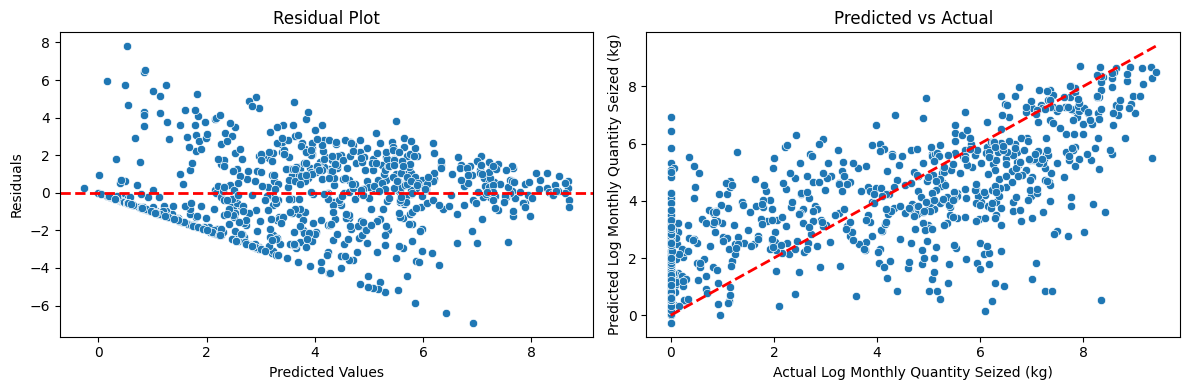

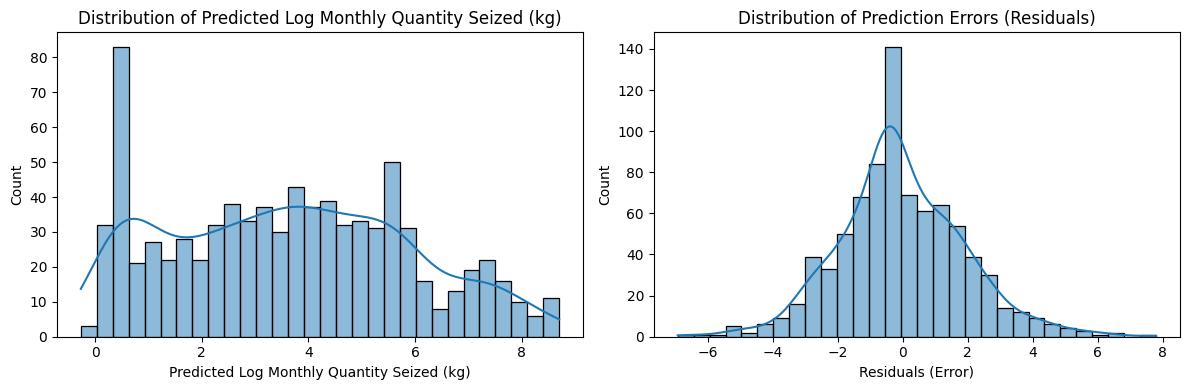

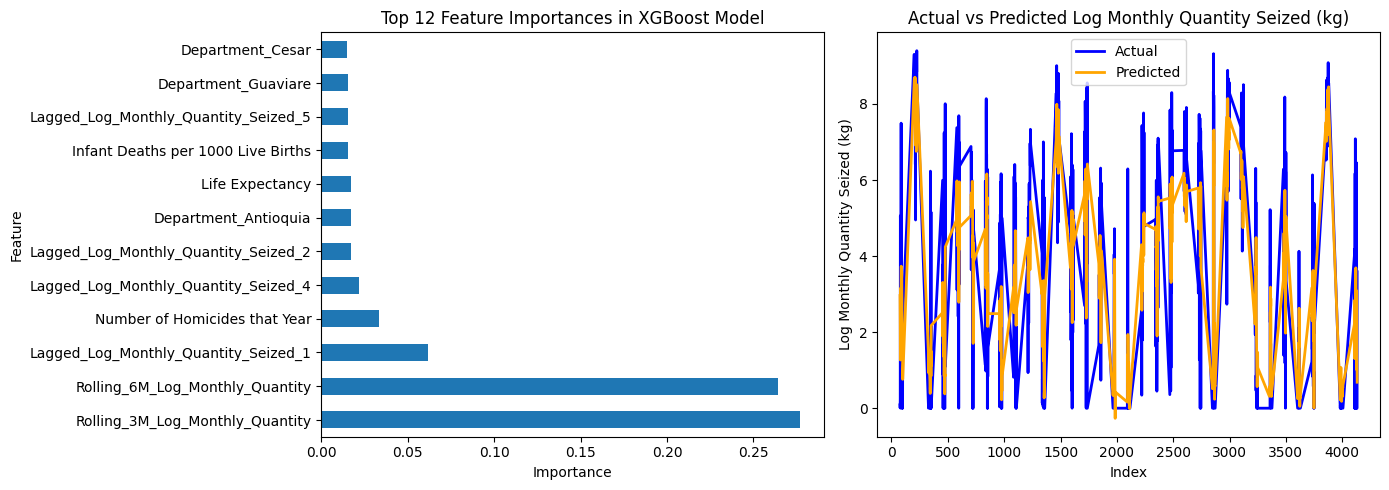

LINEAR REGRESSION
Training MSE: 3.1765555054297607
Testing Mean Squared Error (MSE): 3.8512858183329994
R-squared (R²): 0.572643748821082


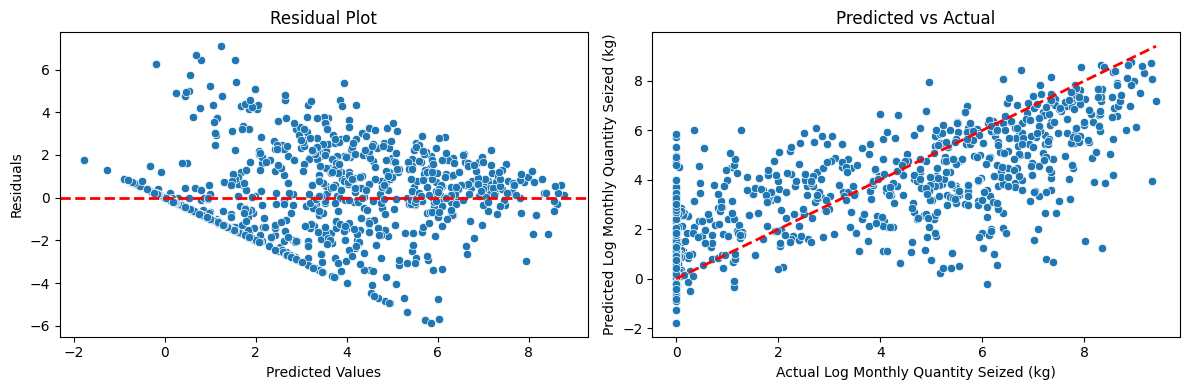

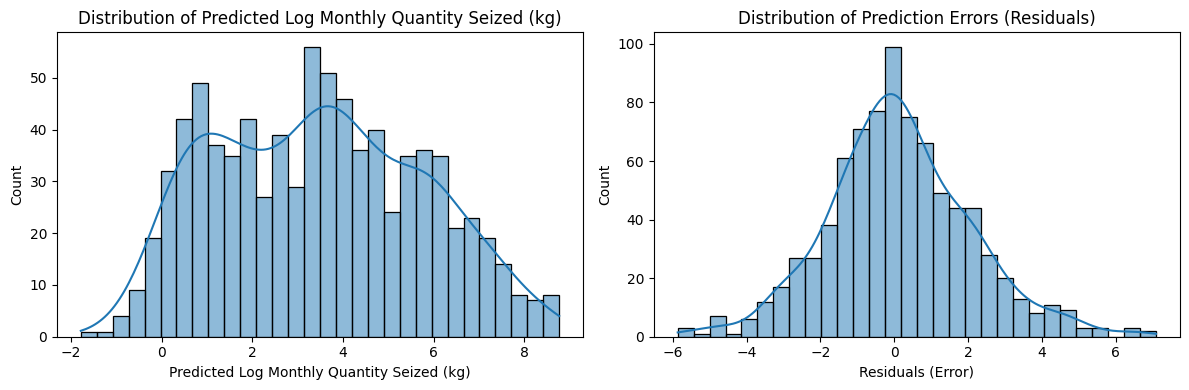

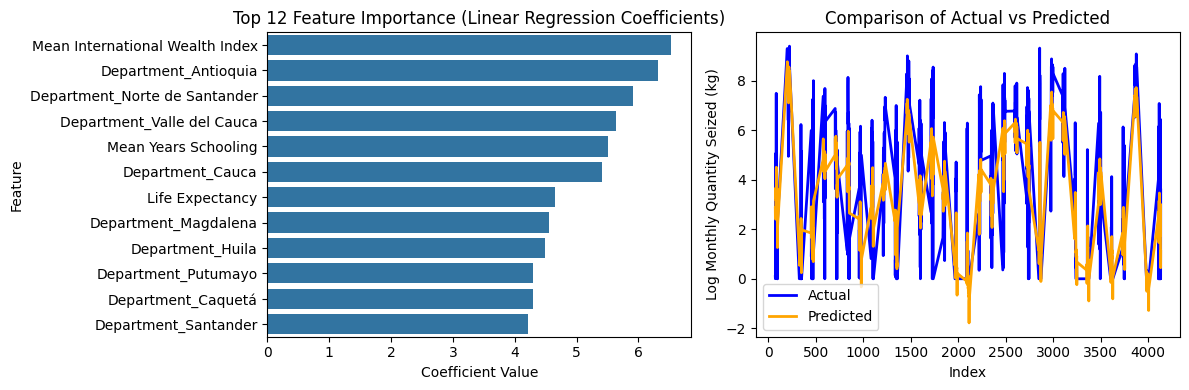

RANDOM FOREST: 
Training Mean Squared Error (MSE): 3.3532602049074614
Testing Mean Squared Error (MSE): 3.829533716710679
R-squared: 0.575057461290909


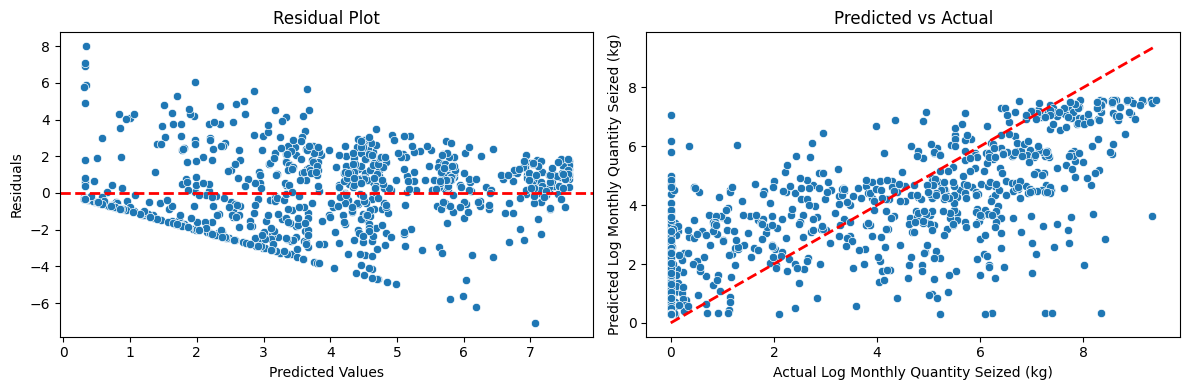

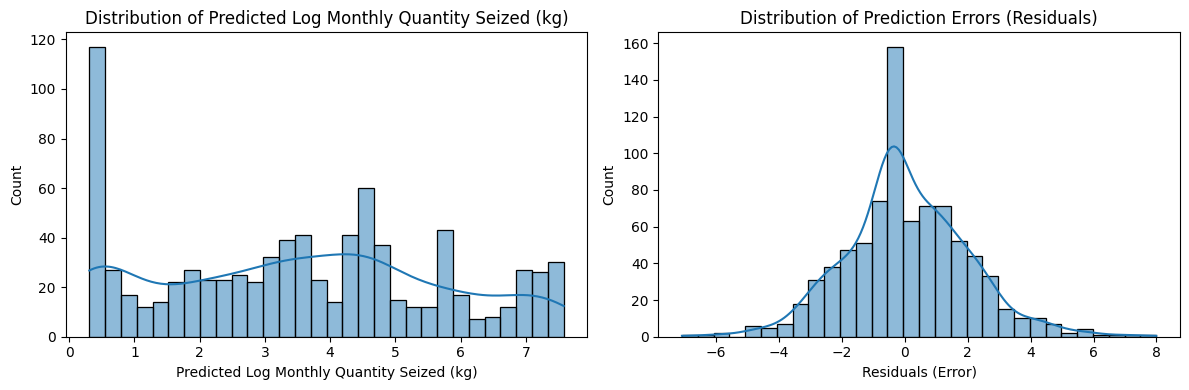

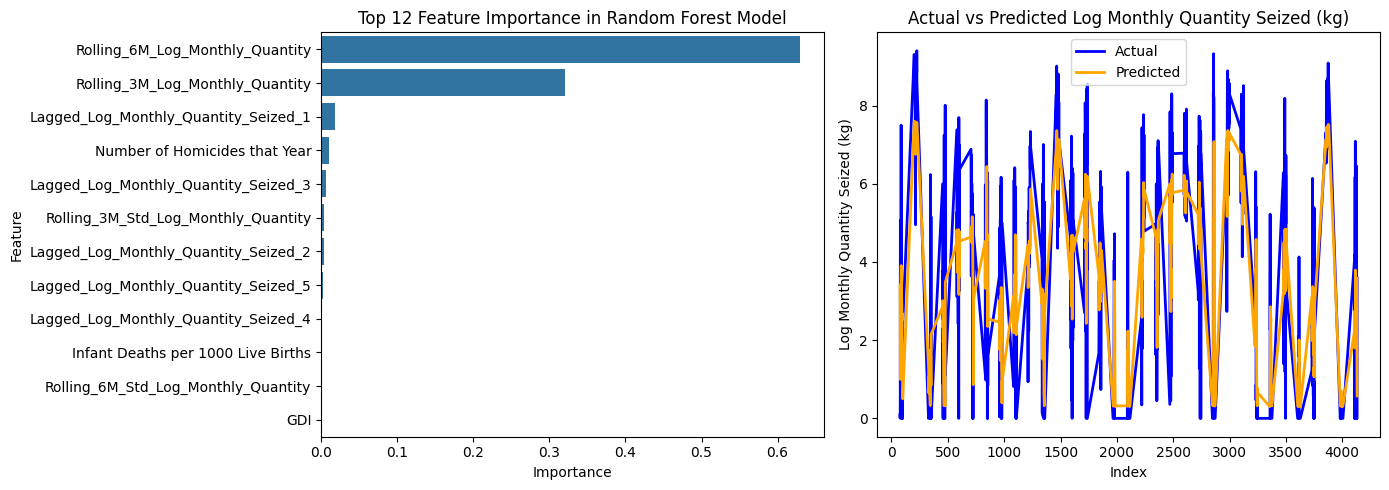

In [ ]:
XGBoost(train_encoded, val_encoded) #3.75
linReg(train_encoded, val_encoded) #3.85
randomForest(train_encoded, val_encoded)#3.83

###Adding season feature

In [ ]:
#@CITATION: CODE ADAPTED FROM CHAT GPT

train = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/train_monthly_12-19_normalized.csv", index_col=0)
test= pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/test_monthly_20-22_normalized.csv", index_col=0)

combined_df = pd.concat([train, test], ignore_index=True)

# Optional: Reset index if needed
combined_df.reset_index(drop=True, inplace=True)

combined_df.tail()

#sort by department then year instead of year then department
combined_df = combined_df.sort_values(by=['Department', 'month_number'])

combined_df = combined_df.drop(columns=['month_year', 'Monthly Quantity Seized (kg)', 'Binned Monthly Quantity'])

#lagged features
combined_df['Lagged_Log_Monthly_Quantity_Seized_1'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(1)
combined_df['Lagged_Log_Monthly_Quantity_Seized_2'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(2)
combined_df['Lagged_Log_Monthly_Quantity_Seized_3'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(3)
combined_df['Lagged_Log_Monthly_Quantity_Seized_4'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(4)
combined_df['Lagged_Log_Monthly_Quantity_Seized_5'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(5)
combined_df['Lagged_Log_Monthly_Quantity_Seized_6'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(6)

#rolling average
combined_df['Rolling_3M_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(lambda x: x.rolling(3, closed='left').mean())
combined_df['Rolling_6M_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(lambda x: x.rolling(6, closed='left').mean())


# Optional: Add lagged rolling standard deviation (for volatility)
combined_df['Rolling_3M_Std_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(lambda x: x.rolling(3, closed='left').std())
combined_df['Rolling_6M_Std_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(lambda x: x.rolling(6, closed='left').std())

#season
combined_df['month'] = combined_df['month_number'] % 12
def get_season(month):
    if month in [11, 0, 1]:      # December, January, February
        return 'Winter'
    elif month in [2, 3, 4]:     # March, April, May
        return 'Spring'
    elif month in [5, 6, 7]:     # June, July, August
        return 'Summer'
    elif month in [8, 9, 10]:    # September, October, November
        return 'Fall'

# Apply the function to create the 'season' column
combined_df['season'] = combined_df['month'].apply(get_season)

# Drop the 'month' column if you no longer need it
combined_df.drop(columns=['month'], inplace=True)

combined_df = pd.get_dummies(combined_df, columns=['season'], drop_first=True)


# drop Nan (first 3 per dept)
combined_lagged = combined_df.dropna(subset=[
  'Lagged_Log_Monthly_Quantity_Seized_1', 'Lagged_Log_Monthly_Quantity_Seized_2', 'Lagged_Log_Monthly_Quantity_Seized_3', 'Lagged_Log_Monthly_Quantity_Seized_4', 'Lagged_Log_Monthly_Quantity_Seized_5', 'Lagged_Log_Monthly_Quantity_Seized_6',
  'Rolling_3M_Log_Monthly_Quantity', 'Rolling_6M_Log_Monthly_Quantity',
  'Rolling_3M_Std_Log_Monthly_Quantity', 'Rolling_6M_Std_Log_Monthly_Quantity'
]).reset_index(drop=True)

'''
#get growth rate
combined_lagged['Lagged_Log_Monthly_Quantity_Seized_2'] = combined_lagged['Lagged_Log_Monthly_Quantity_Seized_2'].replace(0, 1e-10)
combined_lagged['Growth_Rate_Lag_1_2'] = (
    combined_lagged['Lagged_Log_Monthly_Quantity_Seized_1'] - combined_lagged['Lagged_Log_Monthly_Quantity_Seized_2']
) / combined_lagged['Lagged_Log_Monthly_Quantity_Seized_2']
'''

#one hot encode departments
combined_lagged_encoded = pd.get_dummies(combined_lagged, columns=['Department'], drop_first = True) # not drop firsting!

#split train VALIDATION
train_encoded = combined_lagged_encoded[combined_lagged_encoded['month_number'] < 82]
val_encoded = combined_lagged_encoded[(combined_lagged_encoded['month_number'] >= 82) & (combined_lagged_encoded['month_number'] < 107)]
test_encoded = combined_lagged_encoded[combined_lagged_encoded['month_number'] >= 107]
final_train = pd.concat([train_encoded, val_encoded], axis=0)
print("training split: ", len(train_encoded)/(len(train_encoded)+len(val_encoded)+len(test_encoded)))
print("val split: ", len(val_encoded)/(len(train_encoded)+len(val_encoded)+len(test_encoded)))
print("test split: ", len(test_encoded)/(len(train_encoded)+len(val_encoded)+len(test_encoded)))
train_encoded.head()






training split:  0.6031746031746031
val split:  0.1984126984126984
test split:  0.1984126984126984


,month_number,Log Monthly Quantity Seized (kg),Percent Population in Urban Areas,HDI,GDI,Mean International Wealth Index,Infant Deaths per 1000 Live Births,Mean Years Schooling,Log Gross National Income Per Capita in 1000 USD,Life Expectancy,...,Department_Norte de Santander,Department_Putumayo,Department_Quindío,Department_Risaralda,Department_Santander,Department_Sucre,Department_Tolima,Department_Valle del Cauca,Department_Vaupés,Department_Vichada
0,6,0.000000,0.241798,0.241758,0.316327,0.408428,0.388707,0.246288,0.343883,0.408556,...,False,False,False,False,False,False,False,False,False,False
1,7,2.484907,0.241798,0.241758,0.316327,0.408428,0.388707,0.246288,0.343883,0.408556,...,False,False,False,False,False,False,False,False,False,False
2,8,1.181727,0.241798,0.241758,0.316327,0.408428,0.388707,0.246288,0.343883,0.408556,...,False,False,False,False,False,False,False,False,False,False
3,9,0.000000,0.241798,0.241758,0.316327,0.408428,0.388707,0.246288,0.343883,0.408556,...,False,False,False,False,False,False,False,False,False,False
4,10,0.000000,0.241798,0.241758,0.316327,0.408428,0.388707,0.246288,0.343883,0.408556,...,False,False,False,False,False,False,False,False,False,False


XGBoost
Training MSE: 2.76302967778838
Testing Mean Squared Error (MSE): 3.7285111349846822
R-squared (R²): 0.5862673880133886


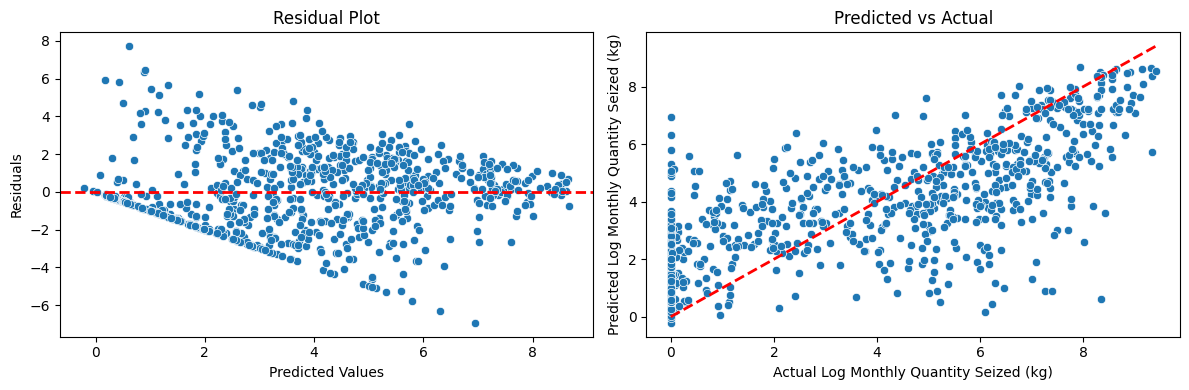

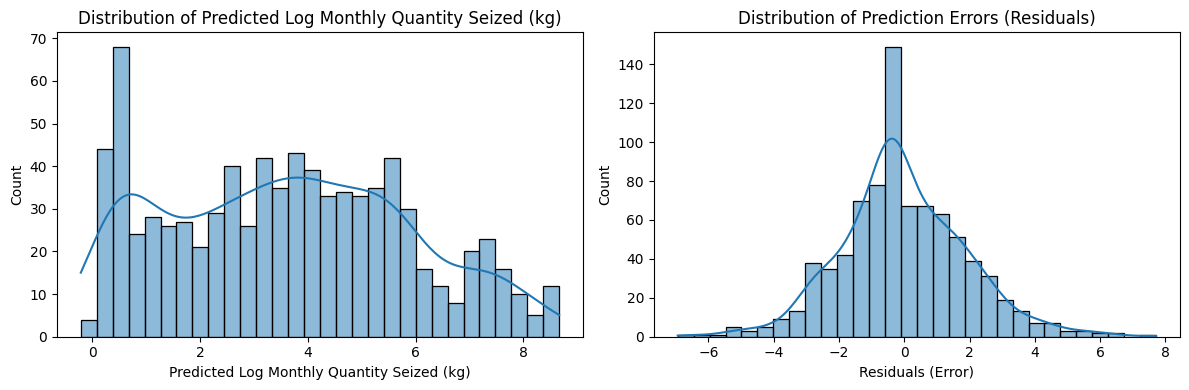

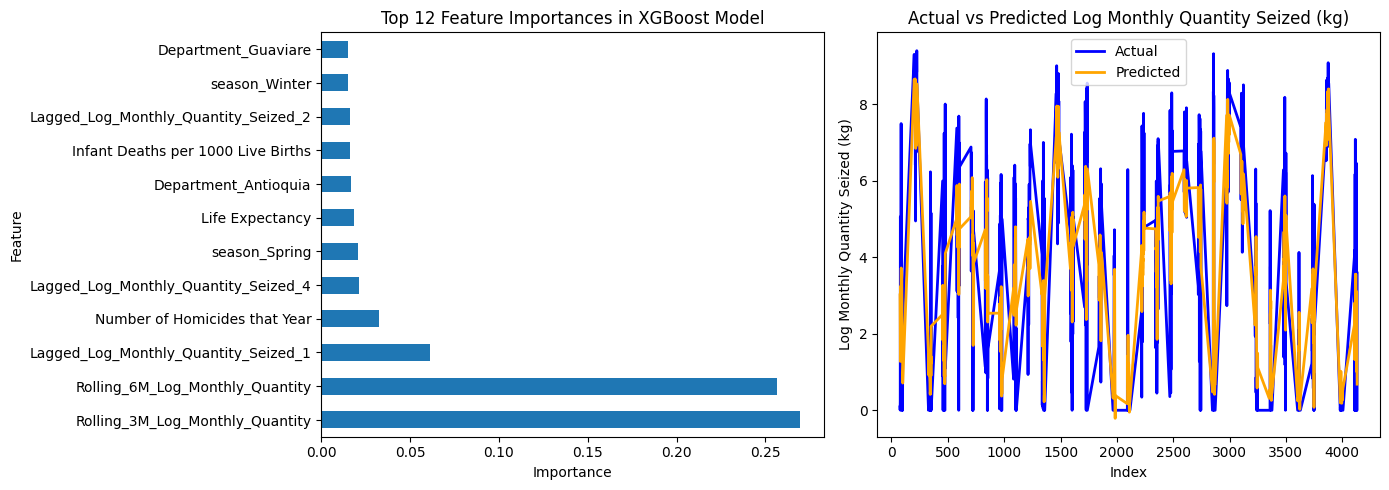

LINEAR REGRESSION
Training MSE: 3.1612499637777747
Testing Mean Squared Error (MSE): 3.8091070800790345
R-squared (R²): 0.5773240941161175


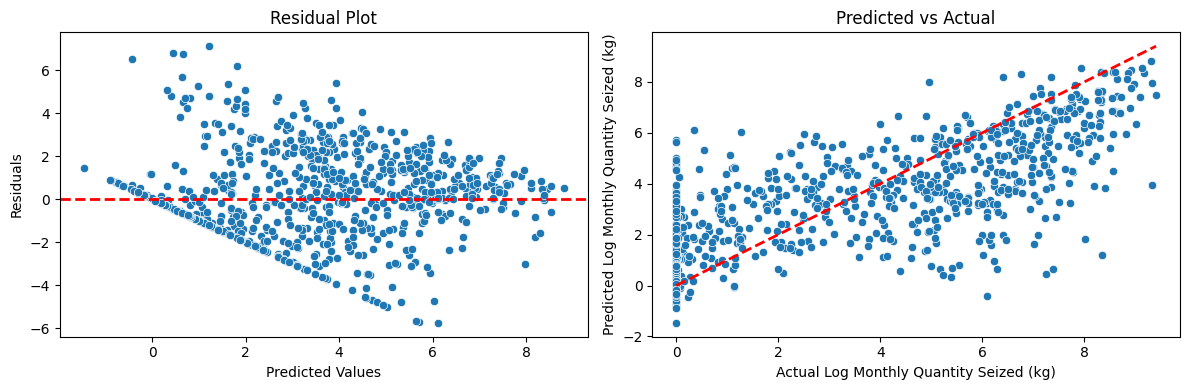

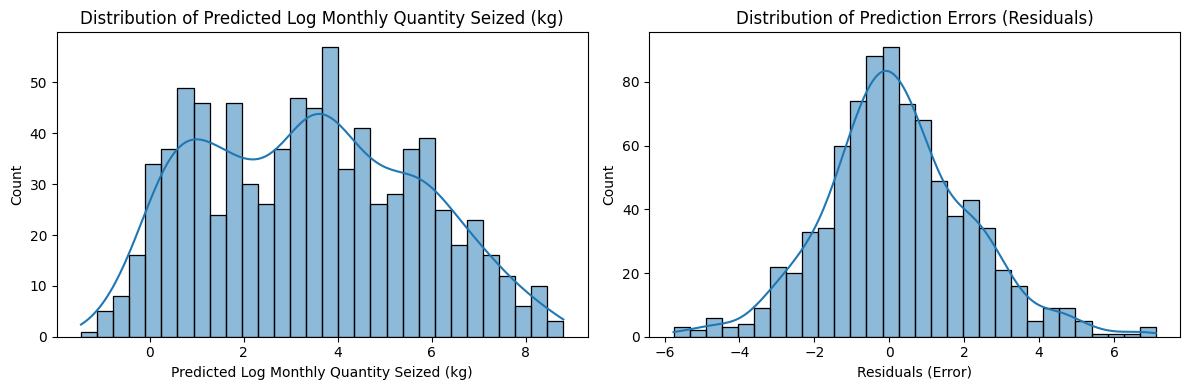

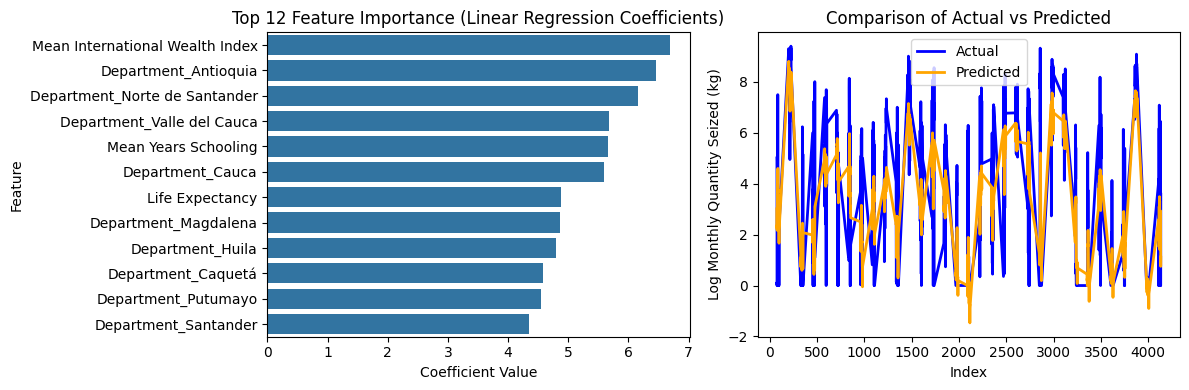

RANDOM FOREST: 
Training Mean Squared Error (MSE): 3.3630605853795177
Testing Mean Squared Error (MSE): 3.810937801053679
R-squared: 0.5771209489615942


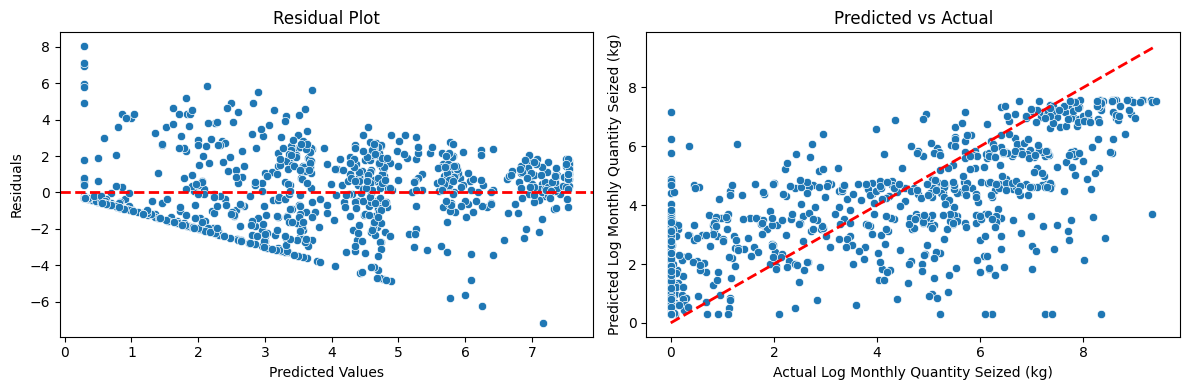

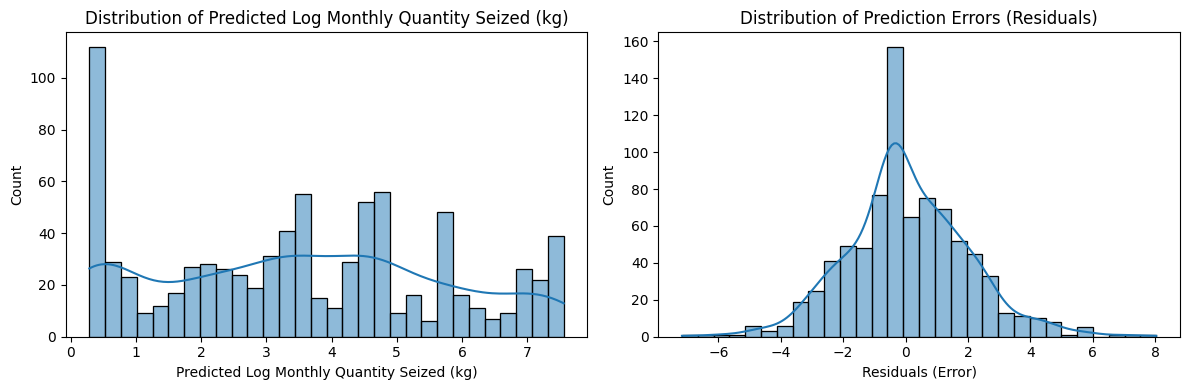

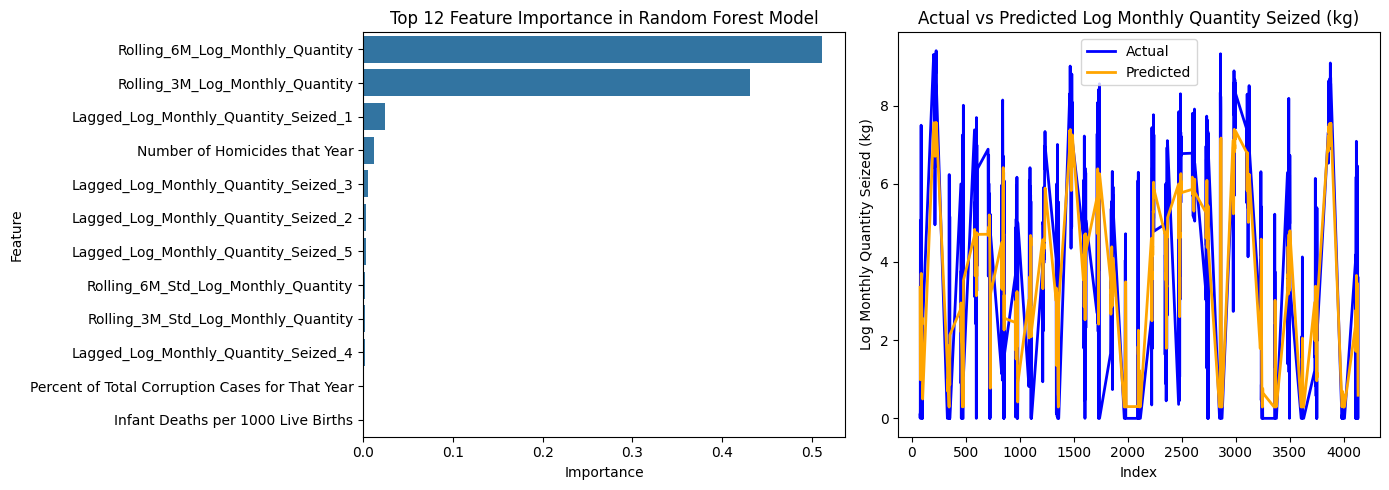

In [ ]:
XGBoost(train_encoded, val_encoded) #3.72
linReg(train_encoded, val_encoded)#3.8
randomForest(train_encoded, val_encoded) #3.81

###Adding month columns

In [ ]:


#@CITATION: CODE ADAPTED FROM CHAT GPT


train = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/train_monthly_12-19_standardized.csv", index_col=0)
test= pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/test_monthly_20-22_standardized.csv", index_col=0)

combined_df = pd.concat([train, test], ignore_index=True)

# Optional: Reset index if needed
combined_df.reset_index(drop=True, inplace=True)

combined_df.tail()

#sort by department then year instead of year then department
combined_df = combined_df.sort_values(by=['Department', 'month_number'])

combined_df = combined_df.drop(columns=['month_year', 'Monthly Quantity Seized (kg)', 'Binned Monthly Quantity'])

#lagged features
combined_df['Lagged_Log_Monthly_Quantity_Seized_1'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(1)
combined_df['Lagged_Log_Monthly_Quantity_Seized_2'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(2)
combined_df['Lagged_Log_Monthly_Quantity_Seized_3'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(3)
combined_df['Lagged_Log_Monthly_Quantity_Seized_4'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(4)
combined_df['Lagged_Log_Monthly_Quantity_Seized_5'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(5)
combined_df['Lagged_Log_Monthly_Quantity_Seized_6'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(6)

#rolling average
combined_df['Rolling_3M_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(lambda x: x.rolling(3, closed='left').mean())
combined_df['Rolling_6M_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(lambda x: x.rolling(6, closed='left').mean())


# Optional: Add lagged rolling standard deviation (for volatility)
combined_df['Rolling_3M_Std_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(lambda x: x.rolling(3, closed='left').std())
combined_df['Rolling_6M_Std_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(lambda x: x.rolling(6, closed='left').std())

#season
combined_df['month'] = combined_df['month_number'] % 12
def get_season(month):
    if month in [11, 0, 1]:      # December, January, February
        return 'Winter'
    elif month in [2, 3, 4]:     # March, April, May
        return 'Spring'
    elif month in [5, 6, 7]:     # June, July, August
        return 'Summer'
    elif month in [8, 9, 10]:    # September, October, November
        return 'Fall'
combined_df['season'] = combined_df['month'].apply(get_season)
combined_df.drop(columns=['month'], inplace=True)
combined_df = pd.get_dummies(combined_df, columns=['season'], drop_first=True)


#Month of year
combined_df['month_of_year'] = combined_df['month_number'] % 12
combined_df['month_sin'] = np.sin(2 * np.pi * combined_df['month_of_year'] / 12)
combined_df['month_cos'] = np.cos(2 * np.pi * combined_df['month_of_year'] / 12)
combined_df.drop(columns=['month_of_year'], inplace=True)

# drop Nan (first 3 per dept)
combined_lagged = combined_df.dropna(subset=[
  'Lagged_Log_Monthly_Quantity_Seized_1', 'Lagged_Log_Monthly_Quantity_Seized_2', 'Lagged_Log_Monthly_Quantity_Seized_3', 'Lagged_Log_Monthly_Quantity_Seized_4', 'Lagged_Log_Monthly_Quantity_Seized_5', 'Lagged_Log_Monthly_Quantity_Seized_6',
  'Rolling_3M_Log_Monthly_Quantity', 'Rolling_6M_Log_Monthly_Quantity',
  'Rolling_3M_Std_Log_Monthly_Quantity', 'Rolling_6M_Std_Log_Monthly_Quantity'
]).reset_index(drop=True)

'''
#get growth rate
combined_lagged['Lagged_Log_Monthly_Quantity_Seized_2'] = combined_lagged['Lagged_Log_Monthly_Quantity_Seized_2'].replace(0, 1e-10)
combined_lagged['Growth_Rate_Lag_1_2'] = (
    combined_lagged['Lagged_Log_Monthly_Quantity_Seized_1'] - combined_lagged['Lagged_Log_Monthly_Quantity_Seized_2']
) / combined_lagged['Lagged_Log_Monthly_Quantity_Seized_2']
'''

#one hot encode departments
combined_lagged_encoded = pd.get_dummies(combined_lagged, columns=['Department'], drop_first = True) # not drop firsting!

#split train VALIDATION
train_encoded = combined_lagged_encoded[combined_lagged_encoded['month_number'] < 82]
val_encoded = combined_lagged_encoded[(combined_lagged_encoded['month_number'] >= 82) & (combined_lagged_encoded['month_number'] < 107)]
test_encoded = combined_lagged_encoded[combined_lagged_encoded['month_number'] >= 107]
final_train = pd.concat([train_encoded, val_encoded], axis=0)
print("training split: ", len(train_encoded)/(len(train_encoded)+len(val_encoded)+len(test_encoded)))
print("val split: ", len(val_encoded)/(len(train_encoded)+len(val_encoded)+len(test_encoded)))
print("test split: ", len(test_encoded)/(len(train_encoded)+len(val_encoded)+len(test_encoded)))
train_encoded.head()






training split:  0.6031746031746031
val split:  0.1984126984126984
test split:  0.1984126984126984


,month_number,Log Monthly Quantity Seized (kg),Percent Population in Urban Areas,HDI,GDI,Mean International Wealth Index,Infant Deaths per 1000 Live Births,Mean Years Schooling,Log Gross National Income Per Capita in 1000 USD,Life Expectancy,...,Department_Norte de Santander,Department_Putumayo,Department_Quindío,Department_Risaralda,Department_Santander,Department_Sucre,Department_Tolima,Department_Valle del Cauca,Department_Vaupés,Department_Vichada
0,6,0.000000,-1.613302,-1.644625,-2.221913,-1.720834,0.643867,-0.531868,-1.745909,-1.340124,...,False,False,False,False,False,False,False,False,False,False
1,7,2.484907,-1.613302,-1.644625,-2.221913,-1.720834,0.643867,-0.531868,-1.745909,-1.340124,...,False,False,False,False,False,False,False,False,False,False
2,8,1.181727,-1.613302,-1.644625,-2.221913,-1.720834,0.643867,-0.531868,-1.745909,-1.340124,...,False,False,False,False,False,False,False,False,False,False
3,9,0.000000,-1.613302,-1.644625,-2.221913,-1.720834,0.643867,-0.531868,-1.745909,-1.340124,...,False,False,False,False,False,False,False,False,False,False
4,10,0.000000,-1.613302,-1.644625,-2.221913,-1.720834,0.643867,-0.531868,-1.745909,-1.340124,...,False,False,False,False,False,False,False,False,False,False


XGBoost
Training MSE: 2.7455491561719896
Testing Mean Squared Error (MSE): 3.7156579094409574
R-squared (R²): 0.5876936405802003


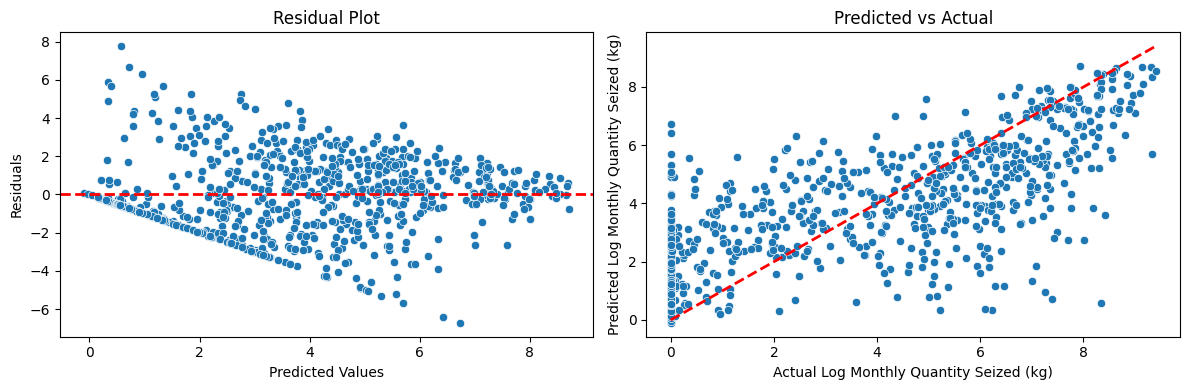

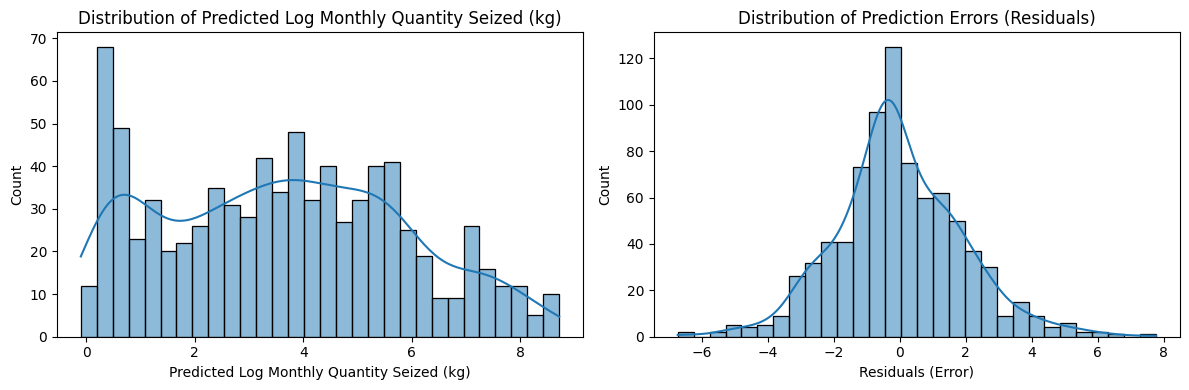

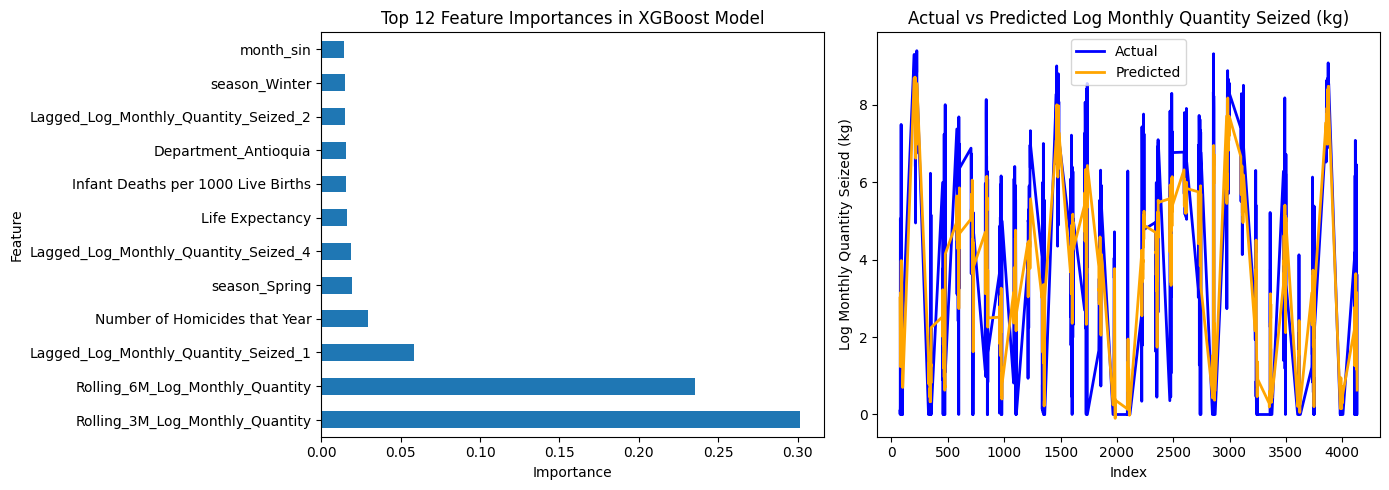

LINEAR REGRESSION
Training MSE: 3.152776734453431
Testing Mean Squared Error (MSE): 3.7764982607469397
R-squared (R²): 0.5809425175316942


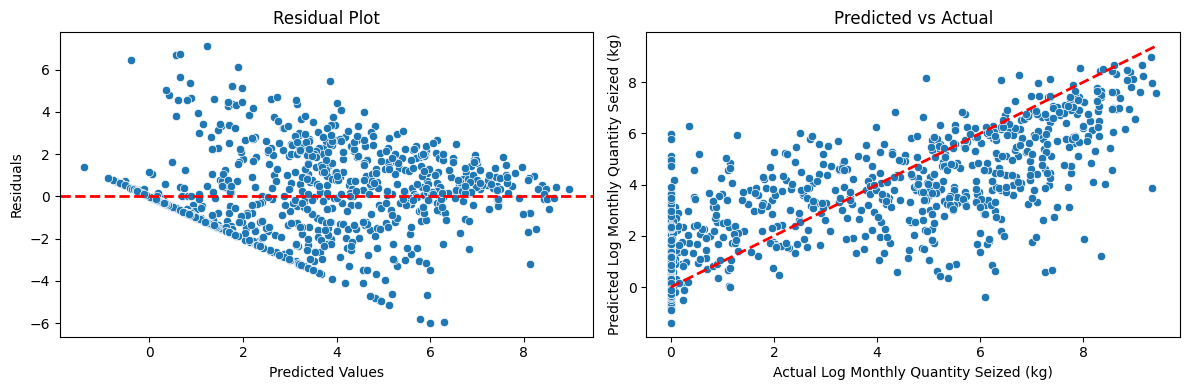

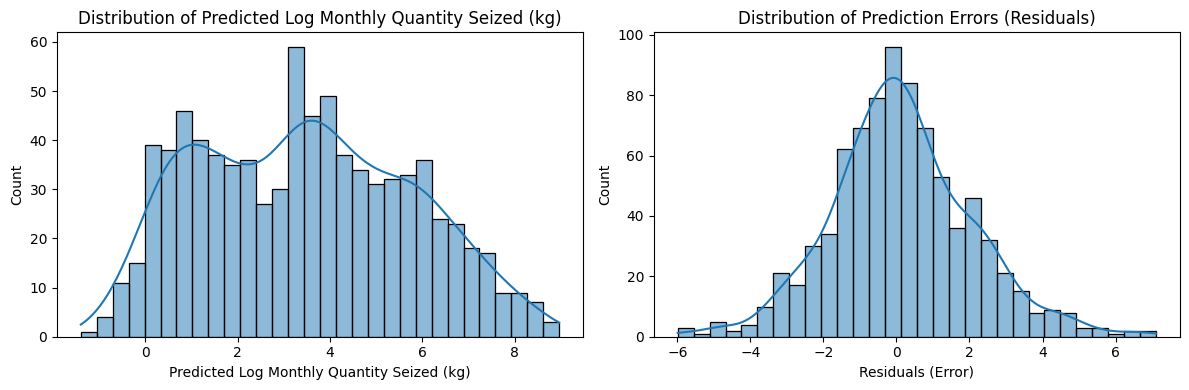

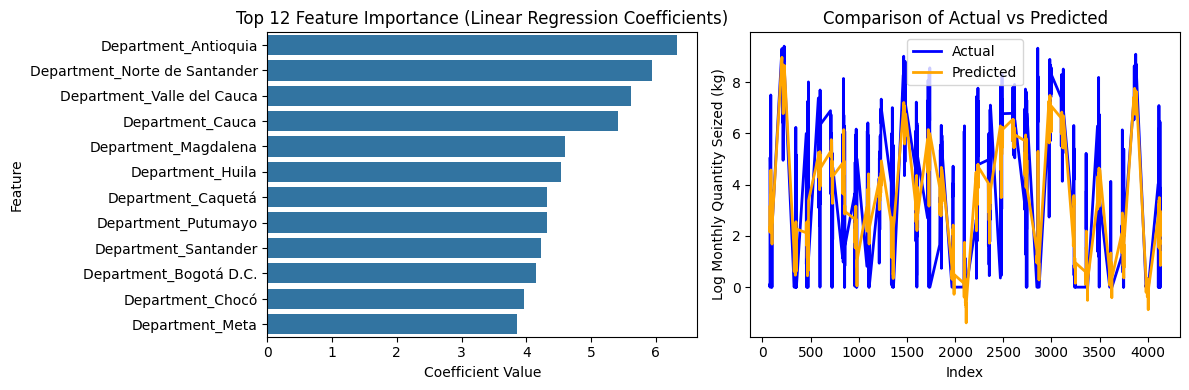

RANDOM FOREST: 
Training Mean Squared Error (MSE): 3.364851326560886
Testing Mean Squared Error (MSE): 3.8198364671235256
R-squared: 0.5761335123621083


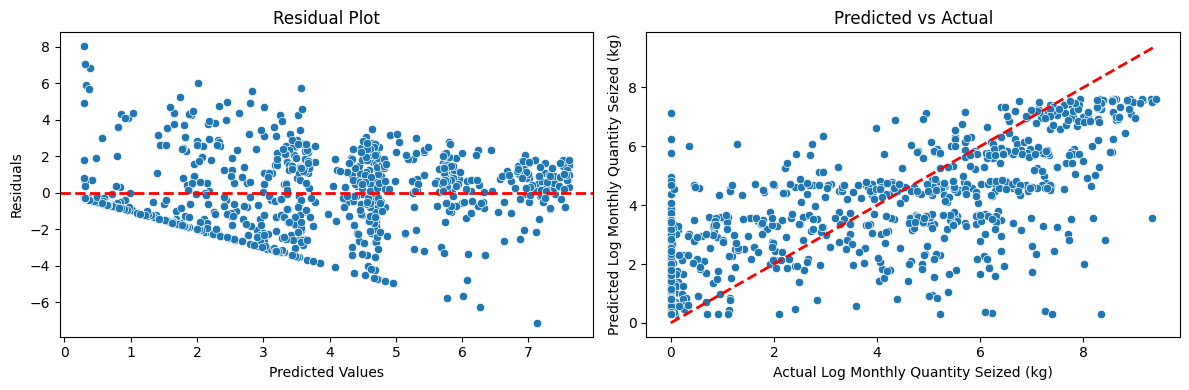

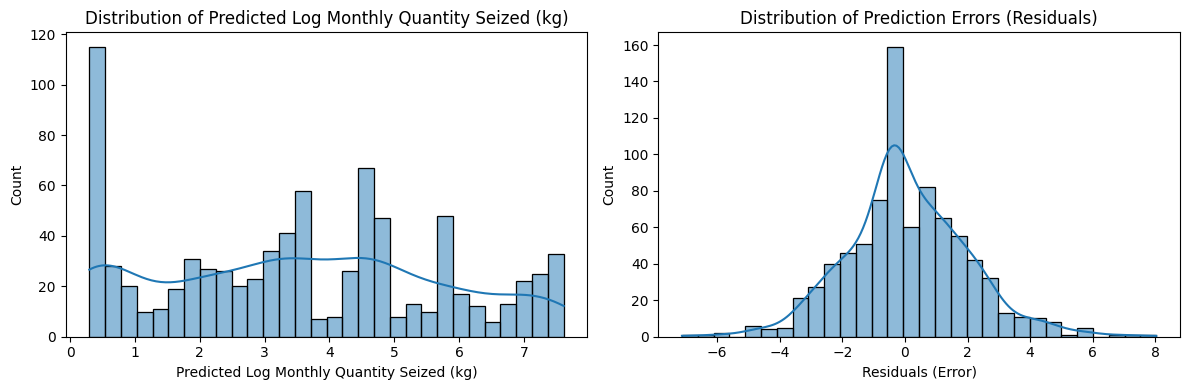

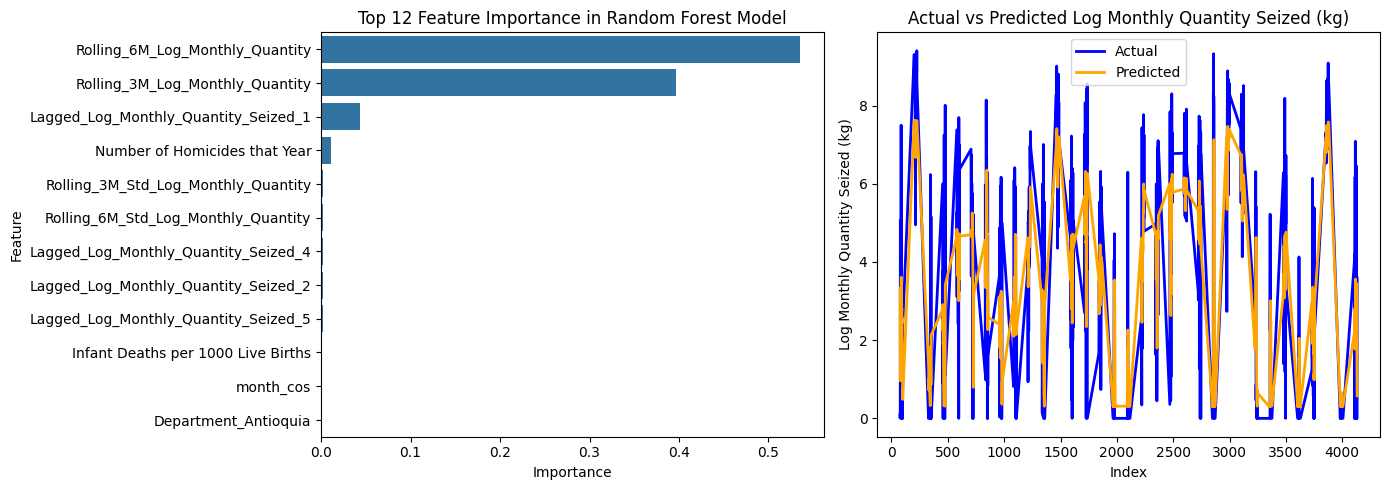

In [ ]:
XGBoost(train_encoded, val_encoded) #3.715
linReg(train_encoded, val_encoded)#3.776
randomForest(train_encoded, val_encoded) #3.819

###

#

###All lag features - weekly

In [ ]:
#@CITATION: CODE ADAPTED FROM CHAT GPT
combined_df = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/combined_weekly_12-22_standardized.csv", index_col=0)

combined_df = combined_df.sort_values(by=['Department', 'week_number'])
combined_df = combined_df.drop(columns=['Quantity Seized (kg)', 'Date'])

combined_df.rename(columns={'Log Quantity Seized (kg)': 'Log Weekly Quantity Seized (kg)'}, inplace=True)

#lagged features
combined_df['Lagged_Log_Weekly_Quantity_Seized_1'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].shift(1)

combined_df['Lagged_Log_Weekly_Quantity_Seized_2'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].shift(2)
combined_df['Lagged_Log_Weekly_Quantity_Seized_3'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].shift(3)
combined_df['Lagged_Log_Weekly_Quantity_Seized_4'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].shift(4)
combined_df['Lagged_Log_Weekly_Quantity_Seized_5'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].shift(5)
combined_df['Lagged_Log_Weekly_Quantity_Seized_6'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].shift(6)
#combined_df['Lagged_Log_Weekly_Quantity_Seized_7'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].shift(7)
#combined_df['Lagged_Log_Weekly_Quantity_Seized_8'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].shift(8)
#combined_df['Lagged_Log_Weekly_Quantity_Seized_9'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].shift(9)
#combined_df['Lagged_Log_Weekly_Quantity_Seized_10'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].shift(10)
#combined_df['Lagged_Log_Weekly_Quantity_Seized_11'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].shift(11)
#combined_df['Lagged_Log_Weekly_Quantity_Seized_12'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].shift(12)

#rolling average
combined_df['Rolling_1M_Log_Weekly_Quantity'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].transform(lambda x: x.rolling(4, closed='left').mean())
combined_df['Rolling_2M_Log_Weekly_Quantity'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].transform(lambda x: x.rolling(8, closed='left').mean())
combined_df['Rolling_3M_Log_Weekly_Quantity'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].transform(lambda x: x.rolling(12, closed='left').mean())
#combined_df['Rolling_4M_Log_Weekly_Quantity'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].transform(lambda x: x.rolling(16, closed='left').mean())
#combined_df['Rolling_5M_Log_Weekly_Quantity'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].transform(lambda x: x.rolling(20, closed='left').mean())
#combined_df['Rolling_6M_Log_Weekly_Quantity'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].transform(lambda x: x.rolling(24, closed='left').mean())




# 1 month std dev
combined_df['Rolling_1M_Std_Log_Weekly_Quantity'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].transform(lambda x: x.rolling(4, closed='left').std())

# 1 month min
combined_df['Rolling_1M_Min_Log_Weekly_Quantity'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].transform(
    lambda x: x.rolling(4, closed='left').min()
)
#1 month max
combined_df['Rolling_1M_Max_Log_Weekly_Quantity'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].transform(
    lambda x: x.rolling(4, closed='left').max()
)
#1 month range
combined_df['Rolling_1M_Range_Log_Weekly_Quantity'] = (
    combined_df['Rolling_1M_Max_Log_Weekly_Quantity'] - combined_df['Rolling_1M_Min_Log_Weekly_Quantity']
)


# 2 month std dev
combined_df['Rolling_2M_Std_Log_Weekly_Quantity'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].transform(lambda x: x.rolling(8, closed='left').std())

# 2 month min
combined_df['Rolling_2M_Min_Log_Weekly_Quantity'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].transform(
    lambda x: x.rolling(8, closed='left').min()
)
#2 month max
combined_df['Rolling_2M_Max_Log_Weekly_Quantity'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].transform(
    lambda x: x.rolling(8, closed='left').max()
)
#2 month range
combined_df['Rolling_2M_Range_Log_Weekly_Quantity'] = (
    combined_df['Rolling_2M_Max_Log_Weekly_Quantity'] - combined_df['Rolling_2M_Min_Log_Weekly_Quantity']
)

# 3 month std dev
combined_df['Rolling_3M_Std_Log_Weekly_Quantity'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].transform(lambda x: x.rolling(12, closed='left').std())

# 3 month min
combined_df['Rolling_3M_Min_Log_Weekly_Quantity'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].transform(
    lambda x: x.rolling(12, closed='left').min()
)
#3 month max
combined_df['Rolling_3M_Max_Log_Weekly_Quantity'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].transform(
    lambda x: x.rolling(12, closed='left').max()
)
#3 month range
combined_df['Rolling_3M_Range_Log_Weekly_Quantity'] = (
    combined_df['Rolling_3M_Max_Log_Weekly_Quantity'] - combined_df['Rolling_3M_Min_Log_Weekly_Quantity']
)

#6 month std dev
combined_df['Rolling_6M_Std_Log_Weekly_Quantity'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].transform(lambda x: x.rolling(24, closed='left').std())

# 6 month minimum
combined_df['Rolling_6M_Min_Log_Weekly_Quantity'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].transform(
    lambda x: x.rolling(24, closed='left').min()
)
#6 month max
combined_df['Rolling_6M_Max_Log_Weekly_Quantity'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].transform(
    lambda x: x.rolling(24, closed='left').max()
)
#6 month range
combined_df['Rolling_6M_Range_Log_Weekly_Quantity'] = (
    combined_df['Rolling_6M_Max_Log_Weekly_Quantity'] - combined_df['Rolling_3M_Min_Log_Weekly_Quantity']
)



#ema 3 month
combined_df['EMA_1M_Log_Weekly_Quantity'] = (
    combined_df
    .groupby('Department')['Log Weekly Quantity Seized (kg)']
    .transform(lambda x: x.shift(1).ewm(span=4, adjust=False).mean())
)

combined_df['EMA_2M_Log_Weekly_Quantity'] = (
    combined_df
    .groupby('Department')['Log Weekly Quantity Seized (kg)']
    .transform(lambda x: x.shift(1).ewm(span=8, adjust=False).mean())
)
combined_df['EMA_3M_Log_Weekly_Quantity'] = (
    combined_df
    .groupby('Department')['Log Weekly Quantity Seized (kg)']
    .transform(lambda x: x.shift(1).ewm(span=12, adjust=False).mean())
)
'''
combined_df['EMA_6M_Log_Weekly_Quantity'] = (
    combined_df
    .groupby('Department')['Log Weekly Quantity Seized (kg)']
    .transform(lambda x: x.shift(1).ewm(span=24, adjust=False).mean())
)
'''
'''
#cumulative sum
combined_df['Cumulative_Log_Weekly_Quantity_Seized'] = combined_df.groupby('Department')['Log Weekly Quantity Seized (kg)'].cumsum().shift(1)

#cumulative sum per year

combined_df['Year'] = 2012 + (combined_df['week_number'] // 52)
combined_df['Cumulative_Log_Weekly_Quantity_Seized_Per_Year'] = (
    combined_df.groupby(['Department', 'Year'])['Log Weekly Quantity Seized (kg)']
    .cumsum()
    .shift(1)
)
combined_df.drop(columns=['Year'], inplace=True)


combined_df['EMA_4M_Log_Weekly_Quantity'] = (
    combined_df
    .groupby('Department')['Log Weekly Quantity Seized (kg)']
    .transform(lambda x: x.shift(1).ewm(span=16, adjust=False).mean())
)

combined_df['EMA_5M_Log_Weekly_Quantity'] = (
    combined_df
    .groupby('Department')['Log Weekly Quantity Seized (kg)']
    .transform(lambda x: x.shift(1).ewm(span=20, adjust=False).mean())
)


combined_df['Momentum_3_6'] = (
    combined_df['Rolling_6M_Log_Weekly_Quantity'].shift(1) - combined_df['Rolling_3M_Log_Weekly_Quantity'].shift(1) )

'''


'''
#season
combined_df['month'] = combined_df['week_number'] // 4 )

def get_season(month):
    if month in [11, 0, 1]:      # December, January, February
        return 'Winter'
    elif month in [2, 3, 4]:     # March, April, May
        return 'Spring'
    elif month in [5, 6, 7]:     # June, July, August
        return 'Summer'
    elif month in [8, 9, 10]:    # September, October, November
        return 'Fall'
combined_df['season'] = combined_df['month'].apply(get_season)
combined_df.drop(columns=['month'], inplace=True)
combined_df.drop(columns=['Year'], inplace=True)
combined_df = pd.get_dummies(combined_df, columns=['season'], drop_first=True)
combined_df['season'].replace({'Winter': 0, 'Spring': 1, 'Summer': 2, 'Fall': 3}, inplace=True)

'''
# drop Nan (first 3 per dept)
combined_lagged = combined_df.dropna(subset=['Lagged_Log_Weekly_Quantity_Seized_1', 'Lagged_Log_Weekly_Quantity_Seized_2', 'Lagged_Log_Weekly_Quantity_Seized_3', 'Lagged_Log_Weekly_Quantity_Seized_4','Lagged_Log_Weekly_Quantity_Seized_5', 'Lagged_Log_Weekly_Quantity_Seized_6',
 'Rolling_1M_Log_Weekly_Quantity', 'Rolling_2M_Log_Weekly_Quantity','Rolling_3M_Log_Weekly_Quantity',
'Rolling_1M_Std_Log_Weekly_Quantity', 'Rolling_1M_Min_Log_Weekly_Quantity', 'Rolling_1M_Max_Log_Weekly_Quantity', 'Rolling_1M_Range_Log_Weekly_Quantity',
  'Rolling_2M_Std_Log_Weekly_Quantity', 'Rolling_2M_Min_Log_Weekly_Quantity', 'Rolling_2M_Max_Log_Weekly_Quantity', 'Rolling_2M_Range_Log_Weekly_Quantity',
  'Rolling_3M_Std_Log_Weekly_Quantity', 'Rolling_3M_Min_Log_Weekly_Quantity', 'Rolling_3M_Max_Log_Weekly_Quantity', 'Rolling_3M_Range_Log_Weekly_Quantity',
  'Rolling_6M_Std_Log_Weekly_Quantity', 'Rolling_6M_Min_Log_Weekly_Quantity', 'Rolling_6M_Max_Log_Weekly_Quantity', 'Rolling_6M_Range_Log_Weekly_Quantity',
 'EMA_1M_Log_Weekly_Quantity', 'EMA_2M_Log_Weekly_Quantity', 'EMA_3M_Log_Weekly_Quantity',

 ]
).reset_index(drop=True)




# drop Nan (first 3 per dept)
'''
combined_lagged = combined_df.dropna(subset=['Lagged_Log_Weekly_Quantity_Seized_1', 'Lagged_Log_Weekly_Quantity_Seized_2', 'Lagged_Log_Weekly_Quantity_Seized_3', 'Lagged_Log_Weekly_Quantity_Seized_4', 'Lagged_Log_Weekly_Quantity_Seized_5', 'Lagged_Log_Weekly_Quantity_Seized_6', 'Lagged_Log_Weekly_Quantity_Seized_7', 'Lagged_Log_Weekly_Quantity_Seized_8',
 'Lagged_Log_Weekly_Quantity_Seized_9', 'Lagged_Log_Weekly_Quantity_Seized_10', 'Lagged_Log_Weekly_Quantity_Seized_11', 'Lagged_Log_Weekly_Quantity_Seized_12',
 'Rolling_1M_Log_Weekly_Quantity', 'Rolling_2M_Log_Weekly_Quantity', 'Rolling_3M_Log_Weekly_Quantity', 'Rolling_4M_Log_Weekly_Quantity', 'Rolling_5M_Log_Weekly_Quantity', 'Rolling_6M_Log_Weekly_Quantity',
 'Rolling_1M_Std_Log_Weekly_Quantity', 'Rolling_1M_Min_Log_Weekly_Quantity', 'Rolling_1M_Max_Log_Weekly_Quantity', 'Rolling_1M_Range_Log_Weekly_Quantity',
  'Rolling_2M_Std_Log_Weekly_Quantity', 'Rolling_2M_Min_Log_Weekly_Quantity', 'Rolling_2M_Max_Log_Weekly_Quantity', 'Rolling_2M_Range_Log_Weekly_Quantity',
  'Rolling_3M_Std_Log_Weekly_Quantity', 'Rolling_3M_Min_Log_Weekly_Quantity', 'Rolling_3M_Max_Log_Weekly_Quantity', 'Rolling_3M_Range_Log_Weekly_Quantity',
  'Rolling_6M_Std_Log_Weekly_Quantity', 'Rolling_6M_Min_Log_Weekly_Quantity', 'Rolling_6M_Max_Log_Weekly_Quantity', 'Rolling_6M_Range_Log_Weekly_Quantity',
 'EMA_1M_Log_Weekly_Quantity', 'EMA_2M_Log_Weekly_Quantity', 'EMA_3M_Log_Weekly_Quantity',  'EMA_6M_Log_Weekly_Quantity',
                                             'Cumulative_Log_Weekly_Quantity_Seized_Per_Year', 'Cumulative_Log_Weekly_Quantity_Seized'
 ]
).reset_index(drop=True)

'''
#  'Rolling_4M_Log_Weekly_Quantity', 'Rolling_5M_Log_Weekly_Quantity', 'Rolling_6M_Log_Weekly_Quantity',  'EMA_4M_Log_Weekly_Quantity', 'EMA_5M_Log_Weekly_Quantity', 'EMA_6M_Log_Weekly_Quantity', 'Momentum_3_6'

#get growth rate
'''
combined_lagged['Lagged_Log_Weekly_Quantity_Seized_1'] = combined_lagged['Lagged_Log_Weekly_Quantity_Seized_1'].replace(0, 1e-10)

combined_lagged['Lagged_Log_Weekly_Quantity_Seized_2'] = combined_lagged['Lagged_Log_Weekly_Quantity_Seized_2'].replace(0, 1e-10)
combined_lagged['Lagged_Log_Weekly_Quantity_Seized_3'] = combined_lagged['Lagged_Log_Weekly_Quantity_Seized_3'].replace(0, 1e-10)
combined_lagged['Lagged_Log_Weekly_Quantity_Seized_4'] = combined_lagged['Lagged_Log_Weekly_Quantity_Seized_4'].replace(0, 1e-10)
combined_lagged['Lagged_Log_Weekly_Quantity_Seized_5'] = combined_lagged['Lagged_Log_Weekly_Quantity_Seized_5'].replace(0, 1e-10)
combined_lagged['Lagged_Log_Weekly_Quantity_Seized_6'] = combined_lagged['Lagged_Log_Weekly_Quantity_Seized_6'].replace(0, 1e-10)

combined_lagged['Growth_Rate_Lag_1_2'] = (
    combined_lagged['Lagged_Log_Weekly_Quantity_Seized_1'] - combined_lagged['Lagged_Log_Weekly_Quantity_Seized_2']
) / combined_lagged['Lagged_Log_Weekly_Quantity_Seized_2']

combined_lagged['Lagged_Log_Weekly_Quantity_Seized_3'] = combined_lagged['Lagged_Log_Weekly_Quantity_Seized_3'].replace(0, 1e-10)
combined_lagged['Growth_Rate_Lag_2_3'] = (
    combined_lagged['Lagged_Log_Weekly_Quantity_Seized_2'] - combined_lagged['Lagged_Log_Weekly_Quantity_Seized_3']
) / combined_lagged['Lagged_Log_Weekly_Quantity_Seized_3']


# Calculate 3-month growth rate
combined_lagged['Growth_Rate_Lag_1_3'] = (
    combined_lagged['Lagged_Log_Weekly_Quantity_Seized_1'] - combined_lagged['Lagged_Log_Weekly_Quantity_Seized_3']
) / combined_lagged['Lagged_Log_Weekly_Quantity_Seized_3']
'''


#one hot encode departments
combined_lagged_encoded = pd.get_dummies(combined_lagged, columns=['Department'], drop_first = True) # not drop firsting!

dept_columns = [col for col in combined_lagged_encoded.columns if col.startswith('Department_')]
for col in dept_columns:
  combined_lagged_encoded[col] = combined_lagged_encoded[col].apply(lambda x: 1 if x == True else 0)


#split train VALIDATION
train_encoded = combined_lagged_encoded[combined_lagged_encoded['week_number'] < 355]
val_encoded = combined_lagged_encoded[(combined_lagged_encoded['week_number'] >= 355) & (combined_lagged_encoded['week_number'] < 463)]
test_encoded = combined_lagged_encoded[combined_lagged_encoded['week_number'] >= 463].reset_index(drop=True)
final_train = pd.concat([train_encoded, val_encoded], axis=0).reset_index(drop=True)
print("training split: ", len(train_encoded)/(len(train_encoded)+len(val_encoded)+len(test_encoded)))
print("val split: ", len(val_encoded)/(len(train_encoded)+len(val_encoded)+len(test_encoded)))
print("test split: ", len(test_encoded)/(len(train_encoded)+len(val_encoded)+len(test_encoded)))
train_encoded.head()




training split:  0.6018181818181818
val split:  0.19636363636363635
test split:  0.2018181818181818


,week_number,Percent Population in Urban Areas,HDI,GDI,Mean International Wealth Index,Infant Deaths per 1000 Live Births,Income Index,Health Index,Educational Index,Mean Years Schooling,...,Department_Norte de Santander,Department_Putumayo,Department_Quindío,Department_Risaralda,Department_Santander,Department_Sucre,Department_Tolima,Department_Valle del Cauca,Department_Vaupés,Department_Vichada
0,24,-1.613379,-1.644489,-2.221961,-1.720798,0.643927,-1.740106,-1.337489,-1.075194,-0.531722,...,0,0,0,0,0,0,0,0,0,0
1,25,-1.613379,-1.644489,-2.221961,-1.720798,0.643927,-1.740106,-1.337489,-1.075194,-0.531722,...,0,0,0,0,0,0,0,0,0,0
2,26,-1.613379,-1.644489,-2.221961,-1.720798,0.643927,-1.740106,-1.337489,-1.075194,-0.531722,...,0,0,0,0,0,0,0,0,0,0
3,27,-1.613379,-1.644489,-2.221961,-1.720798,0.643927,-1.740106,-1.337489,-1.075194,-0.531722,...,0,0,0,0,0,0,0,0,0,0
4,28,-1.613379,-1.644489,-2.221961,-1.720798,0.643927,-1.740106,-1.337489,-1.075194,-0.531722,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
train_encoded.columns

Index(['week_number', 'Percent Population in Urban Areas', 'HDI', 'GDI',
       'Mean International Wealth Index', 'Infant Deaths per 1000 Live Births',
       'Income Index', 'Health Index', 'Educational Index',
       'Mean Years Schooling',
       'Log Gross National Income Per Capita in 1000 USD', 'Life Expectancy',
       'Population Density', 'Number of Corruption Cases',
       'Percent of Total Corruption Cases for That Year',
       'Number of Homicides that Year', 'Gini Coefficient',
       '% Poorest Household (IWI under 30)', 'Log Weekly Quantity Seized (kg)',
       'Border_Department', 'Ocean_department',
       'Lagged_Log_Weekly_Quantity_Seized_1',
       'Lagged_Log_Weekly_Quantity_Seized_2',
       'Lagged_Log_Weekly_Quantity_Seized_3',
       'Lagged_Log_Weekly_Quantity_Seized_4',
       'Lagged_Log_Weekly_Quantity_Seized_5',
       'Lagged_Log_Weekly_Quantity_Seized_6', 'Rolling_1M_Log_Weekly_Quantity',
       'Rolling_2M_Log_Weekly_Quantity', 'Rolling_3M_Log_Weekly

In [ ]:
deptfeatures = ['week_number', 'Percent Population in Urban Areas', 'HDI', 'GDI',
       'Mean International Wealth Index', 'Infant Deaths per 1000 Live Births',
       'Mean Years Schooling',
       'Log Gross National Income Per Capita in 1000 USD', 'Life Expectancy',
       'Population Density', 'Number of Corruption Cases',
       'Percent of Total Corruption Cases for That Year',
       'Number of Homicides that Year', 'Gini Coefficient',
       '% Poorest Household (IWI under 30)', 'Log Weekly Quantity Seized (kg)',
       'Border_Department', 'Ocean_department', 'Department_Antioquia', 'Department_Arauca',
       'Department_Archipiélago de San Andrés, Providencia y Santa Catalina',
       'Department_Atlántico', 'Department_Bogotá D.C.', 'Department_Bolívar',
       'Department_Boyacá', 'Department_Caldas', 'Department_Caquetá',
       'Department_Casanare', 'Department_Cauca', 'Department_Cesar',
       'Department_Chocó', 'Department_Cundinamarca', 'Department_Córdoba',
       'Department_Guainía', 'Department_Guaviare', 'Department_Huila',
       'Department_La Guajira', 'Department_Magdalena', 'Department_Meta',
       'Department_Nariño', 'Department_Norte de Santander',
       'Department_Putumayo', 'Department_Quindío', 'Department_Risaralda',
       'Department_Santander', 'Department_Sucre', 'Department_Tolima',
       'Department_Valle del Cauca', 'Department_Vaupés',
       'Department_Vichada']


columns= [
    'Lagged_Log_Weekly_Quantity_Seized_1',
       'Lagged_Log_Weekly_Quantity_Seized_2',
       'Lagged_Log_Weekly_Quantity_Seized_3',
       'Lagged_Log_Weekly_Quantity_Seized_4',
       'Lagged_Log_Weekly_Quantity_Seized_5',
       'Lagged_Log_Weekly_Quantity_Seized_6', 'Rolling_1M_Log_Weekly_Quantity',
       'Rolling_2M_Log_Weekly_Quantity', 'Rolling_3M_Log_Weekly_Quantity',
       'Rolling_1M_Std_Log_Weekly_Quantity',
       'Rolling_1M_Min_Log_Weekly_Quantity',
       'Rolling_1M_Max_Log_Weekly_Quantity',
       'Rolling_1M_Range_Log_Weekly_Quantity',
       'Rolling_2M_Std_Log_Weekly_Quantity',
       'Rolling_2M_Min_Log_Weekly_Quantity',
       'Rolling_2M_Max_Log_Weekly_Quantity',
       'Rolling_2M_Range_Log_Weekly_Quantity',
       'Rolling_3M_Std_Log_Weekly_Quantity',
       'Rolling_3M_Min_Log_Weekly_Quantity',
       'Rolling_3M_Max_Log_Weekly_Quantity',
       'Rolling_3M_Range_Log_Weekly_Quantity',
       'Rolling_6M_Std_Log_Weekly_Quantity',
       'Rolling_6M_Min_Log_Weekly_Quantity',
       'Rolling_6M_Max_Log_Weekly_Quantity',
       'Rolling_6M_Range_Log_Weekly_Quantity', 'EMA_1M_Log_Weekly_Quantity',
       'EMA_2M_Log_Weekly_Quantity', 'EMA_3M_Log_Weekly_Quantity']

'''
columns = ['Lagged_Log_Weekly_Quantity_Seized_1', 'Lagged_Log_Weekly_Quantity_Seized_2', 'Lagged_Log_Weekly_Quantity_Seized_3', 'Lagged_Log_Weekly_Quantity_Seized_4', 'Lagged_Log_Weekly_Quantity_Seized_5', 'Lagged_Log_Weekly_Quantity_Seized_6', 'Lagged_Log_Weekly_Quantity_Seized_7', 'Lagged_Log_Weekly_Quantity_Seized_8',
 'Lagged_Log_Weekly_Quantity_Seized_9', 'Lagged_Log_Weekly_Quantity_Seized_10', 'Lagged_Log_Weekly_Quantity_Seized_11', 'Lagged_Log_Weekly_Quantity_Seized_12',
 'Rolling_1M_Log_Weekly_Quantity', 'Rolling_2M_Log_Weekly_Quantity', 'Rolling_3M_Log_Weekly_Quantity', 'Rolling_4M_Log_Weekly_Quantity', 'Rolling_5M_Log_Weekly_Quantity', 'Rolling_6M_Log_Weekly_Quantity',
 'Rolling_1M_Std_Log_Weekly_Quantity', 'Rolling_1M_Min_Log_Weekly_Quantity', 'Rolling_1M_Max_Log_Weekly_Quantity', 'Rolling_1M_Range_Log_Weekly_Quantity',
  'Rolling_2M_Std_Log_Weekly_Quantity', 'Rolling_2M_Min_Log_Weekly_Quantity', 'Rolling_2M_Max_Log_Weekly_Quantity', 'Rolling_2M_Range_Log_Weekly_Quantity',
  'Rolling_3M_Std_Log_Weekly_Quantity', 'Rolling_3M_Min_Log_Weekly_Quantity', 'Rolling_3M_Max_Log_Weekly_Quantity', 'Rolling_3M_Range_Log_Weekly_Quantity',
  'Rolling_6M_Std_Log_Weekly_Quantity', 'Rolling_6M_Min_Log_Weekly_Quantity', 'Rolling_6M_Max_Log_Weekly_Quantity', 'Rolling_6M_Range_Log_Weekly_Quantity',
 'EMA_1M_Log_Weekly_Quantity', 'EMA_2M_Log_Weekly_Quantity', 'EMA_3M_Log_Weekly_Quantity','EMA_6M_Log_Weekly_Quantity',
                                             'Cumulative_Log_Weekly_Quantity_Seized_Per_Year', 'Cumulative_Log_Weekly_Quantity_Seized']'''


#'Rolling_6M_Log_Weekly_Quantity', 'EMA_6M_Log_Weekly_Quantity',
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = final_train[columns]
X_test = test_encoded[columns]

print(len(X_train))
print(len(final_train[deptfeatures]))

scaler.fit(X_train)

X_train_standardized = scaler.transform(X_train)
X_test_standardized = scaler.transform(X_test)


print(len(X_train_standardized))
X_train_standardized= pd.DataFrame(X_train_standardized, columns=columns)
X_test_standardized= pd.DataFrame(X_test_standardized, columns=columns)
print(len(X_train_standardized))

final_train2 = pd.concat(
    [final_train[deptfeatures], X_train_standardized], axis=1)
final_train = final_train2
train_encoded = final_train[final_train['week_number'] < 355]
val_encoded = final_train[(final_train['week_number'] >= 355) & (final_train['week_number'] < 463)]


test_encoded = pd.concat(
    [test_encoded[deptfeatures], X_test_standardized], axis=1)

14487
14487
14487
14487


In [ ]:
test_encoded.dtypes

,0
week_number,int64
Percent Population in Urban Areas,float64
HDI,float64
GDI,float64
Mean International Wealth Index,float64
...,...
Rolling_6M_Max_Log_Weekly_Quantity,float64
Rolling_6M_Range_Log_Weekly_Quantity,float64
EMA_1M_Log_Weekly_Quantity,float64
EMA_2M_Log_Weekly_Quantity,float64


In [ ]:
XGBoost(final_train, test_encoded) # 3.28 (test 3.9)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#@CITATION: CODE ADAPTED FROM CHAT GPT
def XGBoost(train_encoded, test_encoded):
  #split train and test sets into features and target var
  X_train = train_encoded.drop(columns=['Log Weekly Quantity Seized (kg)'])
  y_train = train_encoded['Log Weekly Quantity Seized (kg)']
  X_test = test_encoded.drop(columns=['Log Weekly Quantity Seized (kg)'])
  y_test = test_encoded['Log Weekly Quantity Seized (kg)']


  xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_estimators=800, learning_rate=0.01, max_depth=1, min_child_weight=10, colsample_bytree=1, colsample_bylevel=1, colsample_bynode=1.0, alpha=0.1)

  # Fit the model
  xgb_model.fit(X_train, y_train)


  # Make predictions on the training set
  y_train_pred = xgb_model.predict(X_train)

  # Make predictions on the test set
  y_pred = xgb_model.predict(X_test)

  # Evaluate the model on the training set
  mse_train = mean_squared_error(y_train, y_train_pred)
  train_r2 = r2_score(y_train, y_train_pred)

  # Evaluate the model on the test set
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  # Print the results
  print("XGBoost")
  print(f"Training MSE: {mse_train}")
  print(f"Testing Mean Squared Error (MSE): {mse}")
  print(f"R-squared (R²): {r2}")

  #PLOTS

  # Residual Plot and Prediction vs Actual
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))

  # Residual Plot
  residuals = y_test - y_pred
  sns.scatterplot(x=y_pred, y=residuals, ax=axes[0])
  axes[0].axhline(0, color='r', linestyle='--', lw=2)
  axes[0].set_xlabel("Predicted Values")
  axes[0].set_ylabel("Residuals")
  axes[0].set_title("Residual Plot")

  # Prediction vs Actual
  sns.scatterplot(x=y_test, y=y_pred, ax=axes[1])
  axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
  axes[1].set_xlabel("Actual Log Weekly Quantity Seized (kg)")
  axes[1].set_ylabel("Predicted Log Weekly Quantity Seized (kg)")
  axes[1].set_title("Predicted vs Actual")

  plt.tight_layout()
  plt.show()

  # Distribution of Predictions and Error Distribution
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))

  # Distribution of Predictions
  sns.histplot(y_pred, bins=30, kde=True, ax=axes[0])
  axes[0].set_xlabel("Predicted Log Weekly Quantity Seized (kg)")
  axes[0].set_title("Distribution of Predicted Log Weekly Quantity Seized (kg)")

  # Error Distribution
  sns.histplot(residuals, bins=30, kde=True, ax=axes[1])
  axes[1].set_xlabel("Residuals (Error)")
  axes[1].set_title("Distribution of Prediction Errors (Residuals)")

  plt.tight_layout()
  plt.show()

  # Feature Importance and Actual vs Predicted Comparison on one line
  fig, axes = plt.subplots(1, 2, figsize=(14, 5))

  # Top 12 Feature Importances
  importances = xgb_model.feature_importances_
  feature_importance = pd.Series(importances, index=X_train.columns)
  feature_importance.nlargest(12).plot(kind='barh', ax=axes[0])
  axes[0].set_title("Top 12 Feature Importances in XGBoost Model")
  axes[0].set_xlabel("Importance")
  axes[0].set_ylabel("Feature")

  # Comparison of Actual vs Predicted
  comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
  comparison_df.sort_index(inplace=True)

  axes[1].plot(comparison_df.index, comparison_df['Actual'], label='Actual', color='blue', linewidth=2)
  axes[1].plot(comparison_df.index, comparison_df['Predicted'], label='Predicted', color='orange', linewidth=2)
  axes[1].set_xlabel("Index")
  axes[1].set_ylabel("Log Weekly Quantity Seized (kg)")
  axes[1].set_title("Actual vs Predicted Log Weekly Quantity Seized (kg)")
  axes[1].legend()

  plt.tight_layout()
  plt.show()

  results_df = X_test.copy()
  results_df['Actual'] = y_test
  results_df['Predicted'] = y_pred
  results_df['Residual'] = results_df['Actual'] - results_df['Predicted']

  # Identify the department for each row
  department_cols = [col for col in results_df.columns if col.startswith('Department_')]
  results_df['Department'] = results_df[department_cols].idxmax(axis=1).str.replace('Department_', '')

  # Calculate MSE for each department
  mse_per_department = results_df.groupby('Department').apply(lambda x: mean_squared_error(x['Actual'], x['Predicted'])).reset_index()
  mse_per_department.columns = ['Department', 'MSE']

  # Print the MSE per department
  mse_per_department.sort_values(by='MSE', ascending=False, inplace=True)
  print(mse_per_department)

  departments = results_df['Department'].unique()
  for department in departments:
      dept_data = results_df[results_df['Department'] == department].sort_values(by='week_number')

      plt.figure(figsize=(10, 5))
      plt.plot(dept_data['week_number'], dept_data['Actual'], label='Actual', color='blue')
      plt.plot(dept_data['week_number'], dept_data['Predicted'], label='Predicted', color='orange')
      plt.title(f"{department} - Actual vs Predicted Log Weekly Quantity Seized (kg)")
      plt.xlabel("Week Number")
      plt.ylabel("Log Weekly Quantity Seized (kg)")
      plt.legend()
      plt.grid()
      plt.show()






###All lag features - monthly:


In [ ]:
train['Department'].unique()

array(['Amazonas', 'Antioquia', 'Arauca',
       'Archipiélago de San Andrés, Providencia y Santa Catalina',
       'Atlántico', 'Bogotá D.C.', 'Bolívar', 'Boyacá', 'Caldas',
       'Caquetá', 'Casanare', 'Cauca', 'Cesar', 'Chocó', 'Cundinamarca',
       'Córdoba', 'Guainía', 'Guaviare', 'Huila', 'La Guajira',
       'Magdalena', 'Meta', 'Nariño', 'Norte de Santander', 'Putumayo',
       'Quindío', 'Risaralda', 'Santander', 'Sucre', 'Tolima',
       'Valle del Cauca', 'Vaupés', 'Vichada'], dtype=object)

In [ ]:

#@CITATION: CODE ADAPTED FROM CHAT GPT

train = pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/train_monthly_12-19_standardized.csv", index_col=0)
test= pd.read_csv("/content/drive/MyDrive/Fall '24/COS 397 ML IW/Final Data/test_monthly_20-22_standardized.csv", index_col=0)



combined_df = pd.concat([train, test], ignore_index=True)

#Remove archipeg, choco, narino, vichada.
#departments_to_exclude = ['Archipiélago de San Andrés, Providencia y Santa Catalina', 'Nariño', 'Vichada', 'Chocó' ]  # Replace with your actual department names
# Remove rows where Department is in the list of departments to exclude
#combined_df = combined_df[~combined_df['Department'].isin(departments_to_exclude)]


# Optional: Reset index if needed
combined_df.reset_index(drop=True, inplace=True)

border_depts = ['Nariño', 'Putumayo', 'Amazonas', 'Vaupés', 'Guainia', 'Vichada', 'Arauca', 'Norte de Santander', 'Cesar', 'La Guajira', 'Choco' ]
ocean_depts = ['Nariño', 'Cauca', 'Valle del Cauca', 'Chocó', 'Antioquia', 'Córdoba', 'Sucre', 'Bolívar', 'Atlántico', 'Magdalena', 'La Guajira']


peru_ecuador_border = ['Nariño', 'Putumayo', 'Amazonas']
brasil_border = ['Amazonas', 'Vaupés', 'Guainia']
venezuela_border = ['Arauca', 'Norte de Santander', 'Cesar', 'La Guajira']

#combined_df['Border_department'] = combined_df['Department'].apply(lambda x: 1 if x in border_depts else 0)
combined_df['Ocean_department'] = combined_df['Department'].apply(lambda x: 1 if x in ocean_depts else 0)
combined_df['Peru_Ecuador_border_department'] = combined_df['Department'].apply(lambda x: 1 if x in peru_ecuador_border else 0)
combined_df['Brasil_border_department'] = combined_df['Department'].apply(lambda x: 1 if x in brasil_border else 0)
combined_df['Venezuela_border_department'] = combined_df['Department'].apply(lambda x: 1 if x in venezuela_border else 0)





#sort by department then year instead of year then department
combined_df = combined_df.sort_values(by=['Department', 'month_number'])

combined_df = combined_df.drop(columns=['month_year', 'Monthly Quantity Seized (kg)', 'Binned Monthly Quantity'])





#lagged features
combined_df['Lagged_Log_Monthly_Quantity_Seized_1'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(1)
combined_df['Lagged_Log_Monthly_Quantity_Seized_2'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(2)
combined_df['Lagged_Log_Monthly_Quantity_Seized_3'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(3)
combined_df['Lagged_Log_Monthly_Quantity_Seized_4'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(4)
combined_df['Lagged_Log_Monthly_Quantity_Seized_5'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(5)
combined_df['Lagged_Log_Monthly_Quantity_Seized_6'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].shift(6)
#rolling average
combined_df['Rolling_3M_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(lambda x: x.rolling(3, closed='left').mean())


# Add lagged rolling standard deviation (for volatility)
combined_df['Rolling_3M_Std_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(lambda x: x.rolling(3, closed='left').std())

# 3 month minimum
combined_df['Rolling_3M_Min_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(
    lambda x: x.rolling(3, closed='left').min()
)
#3 month max
combined_df['Rolling_3M_Max_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(
    lambda x: x.rolling(3, closed='left').max()
)
#3 month range
combined_df['Rolling_3M_Range_Log_Monthly_Quantity'] = (
    combined_df['Rolling_3M_Max_Log_Monthly_Quantity'] - combined_df['Rolling_3M_Min_Log_Monthly_Quantity']
)

# 6 month minimum
combined_df['Rolling_6M_Min_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(
    lambda x: x.rolling(6, closed='left').min()
)
#6 month max
combined_df['Rolling_6M_Max_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(
    lambda x: x.rolling(6, closed='left').max()
)
#6 month range
combined_df['Rolling_6M_Range_Log_Monthly_Quantity'] = (
    combined_df['Rolling_6M_Max_Log_Monthly_Quantity'] - combined_df['Rolling_3M_Min_Log_Monthly_Quantity']
)

combined_df['Rolling_6M_Std_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(lambda x: x.rolling(6, closed='left').std())

#6 month ones
'''
combined_df['Rolling_6M_Log_Monthly_Quantity'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].transform(lambda x: x.rolling(6, closed='left').mean())

combined_df['EMA_6M_Log_Monthly_Quantity'] = (
    combined_df
    .groupby('Department')['Log Monthly Quantity Seized (kg)']
    .transform(lambda x: x.shift(1).ewm(span=6, adjust=False).mean())
)
combined_df['Momentum_3_6'] = (
    combined_df['Rolling_6M_Log_Monthly_Quantity'].shift(1) - combined_df['Rolling_3M_Log_Monthly_Quantity'].shift(1) )
# Calculate 6-month growth rate
combined_lagged['Lagged_Log_Monthly_Quantity_Seized_6'] = combined_lagged['Lagged_Log_Monthly_Quantity_Seized_6'].replace(0, 1e-10)
combined_lagged['Growth_Rate_Lag_1_6'] = (
    combined_lagged['Lagged_Log_Monthly_Quantity_Seized_1'] - combined_lagged['Lagged_Log_Monthly_Quantity_Seized_6']
) / combined_lagged['Lagged_Log_Monthly_Quantity_Seized_6']
'''


#cumulative sum
#combined_df['Cumulative_Log_Monthly_Quantity_Seized'] = combined_df.groupby('Department')['Log Monthly Quantity Seized (kg)'].cumsum().shift(1)

#cumulative sum per year
combined_df['Year'] = 2012 + (combined_df['month_number'] // 12)
combined_df['Cumulative_Log_Monthly_Quantity_Seized_Per_Year'] = (
    combined_df.groupby(['Department', 'Year'])['Log Monthly Quantity Seized (kg)']
    .cumsum()
    .shift(1)
)

#ema 3 month
combined_df['EMA_3M_Log_Monthly_Quantity'] = (
    combined_df
    .groupby('Department')['Log Monthly Quantity Seized (kg)']
    .transform(lambda x: x.shift(1).ewm(span=3, adjust=False).mean())
)
combined_df['EMA_6M_Log_Monthly_Quantity'] = (
    combined_df
    .groupby('Department')['Log Monthly Quantity Seized (kg)']
    .transform(lambda x: x.shift(1).ewm(span=6, adjust=False).mean())
)


#season
combined_df['month'] = combined_df['month_number'] % 12
def get_season(month):
    if month in [11, 0, 1]:      # December, January, February
        return 'Winter'
    elif month in [2, 3, 4]:     # March, April, May
        return 'Spring'
    elif month in [5, 6, 7]:     # June, July, August
        return 'Summer'
    elif month in [8, 9, 10]:    # September, October, November
        return 'Fall'
combined_df['season'] = combined_df['month'].apply(get_season)
combined_df.drop(columns=['month'], inplace=True)
combined_df.drop(columns=['Year'], inplace=True)
combined_df = pd.get_dummies(combined_df, columns=['season'], drop_first=True)

'''
#Month of year
combined_df['month_of_year'] = combined_df['month_number'] % 12
combined_df['month_sin'] = np.sin(2 * np.pi * combined_df['month_of_year'] / 12)
combined_df['month_cos'] = np.cos(2 * np.pi * combined_df['month_of_year'] / 12)
combined_df.drop(columns=['month_of_year'], inplace=True)
'''


# drop Nan (first 3 per dept)
combined_lagged = combined_df.dropna(subset=['Lagged_Log_Monthly_Quantity_Seized_1',
       'Lagged_Log_Monthly_Quantity_Seized_2',
       'Lagged_Log_Monthly_Quantity_Seized_3',
       'Lagged_Log_Monthly_Quantity_Seized_4',
       'Lagged_Log_Monthly_Quantity_Seized_5',
       'Lagged_Log_Monthly_Quantity_Seized_6',
       'Rolling_3M_Log_Monthly_Quantity',
       'Rolling_3M_Std_Log_Monthly_Quantity',
       'Rolling_3M_Min_Log_Monthly_Quantity',
       'Rolling_3M_Max_Log_Monthly_Quantity',
       'Rolling_3M_Range_Log_Monthly_Quantity',
       'Rolling_6M_Min_Log_Monthly_Quantity',
       'Rolling_6M_Max_Log_Monthly_Quantity',
       'Rolling_6M_Range_Log_Monthly_Quantity',
       'Rolling_6M_Std_Log_Monthly_Quantity',
       'Cumulative_Log_Monthly_Quantity_Seized_Per_Year',
       'EMA_3M_Log_Monthly_Quantity', 'EMA_6M_Log_Monthly_Quantity',
       'season_Spring', 'season_Summer', 'season_Winter']).reset_index(drop=True)


#get growth rate
combined_lagged['Lagged_Log_Monthly_Quantity_Seized_1'] = combined_lagged['Lagged_Log_Monthly_Quantity_Seized_1'].replace(0, 1e-10)

combined_lagged['Lagged_Log_Monthly_Quantity_Seized_2'] = combined_lagged['Lagged_Log_Monthly_Quantity_Seized_2'].replace(0, 1e-10)
combined_lagged['Lagged_Log_Monthly_Quantity_Seized_3'] = combined_lagged['Lagged_Log_Monthly_Quantity_Seized_3'].replace(0, 1e-10)
combined_lagged['Lagged_Log_Monthly_Quantity_Seized_4'] = combined_lagged['Lagged_Log_Monthly_Quantity_Seized_4'].replace(0, 1e-10)
combined_lagged['Lagged_Log_Monthly_Quantity_Seized_5'] = combined_lagged['Lagged_Log_Monthly_Quantity_Seized_5'].replace(0, 1e-10)
combined_lagged['Lagged_Log_Monthly_Quantity_Seized_6'] = combined_lagged['Lagged_Log_Monthly_Quantity_Seized_6'].replace(0, 1e-10)

combined_lagged['Growth_Rate_Lag_1_2'] = (
    combined_lagged['Lagged_Log_Monthly_Quantity_Seized_1'] - combined_lagged['Lagged_Log_Monthly_Quantity_Seized_2']
) / combined_lagged['Lagged_Log_Monthly_Quantity_Seized_2']

combined_lagged['Lagged_Log_Monthly_Quantity_Seized_3'] = combined_lagged['Lagged_Log_Monthly_Quantity_Seized_3'].replace(0, 1e-10)
combined_lagged['Growth_Rate_Lag_2_3'] = (
    combined_lagged['Lagged_Log_Monthly_Quantity_Seized_2'] - combined_lagged['Lagged_Log_Monthly_Quantity_Seized_3']
) / combined_lagged['Lagged_Log_Monthly_Quantity_Seized_3']


# Calculate 3-month growth rate
combined_lagged['Growth_Rate_Lag_1_3'] = (
    combined_lagged['Lagged_Log_Monthly_Quantity_Seized_1'] - combined_lagged['Lagged_Log_Monthly_Quantity_Seized_3']
) / combined_lagged['Lagged_Log_Monthly_Quantity_Seized_3']



#one hot encode departments
combined_lagged_encoded = pd.get_dummies(combined_lagged, columns=['Department'], drop_first = True) # not drop firsting!

dept_columns = [col for col in combined_lagged_encoded.columns if col.startswith('Department_')]
for col in dept_columns:
  combined_lagged_encoded[col] = combined_lagged_encoded[col].apply(lambda x: 1 if x == True else 0)


#split train VALIDATION
train_encoded = combined_lagged_encoded[combined_lagged_encoded['month_number'] < 82]
val_encoded = combined_lagged_encoded[(combined_lagged_encoded['month_number'] >= 82) & (combined_lagged_encoded['month_number'] < 107)]
test_encoded = combined_lagged_encoded[combined_lagged_encoded['month_number'] >= 107].reset_index(drop=True)
final_train = pd.concat([train_encoded, val_encoded], axis=0).reset_index(drop=True)
print("training split: ", len(train_encoded)/(len(train_encoded)+len(val_encoded)+len(test_encoded)))
print("val split: ", len(val_encoded)/(len(train_encoded)+len(val_encoded)+len(test_encoded)))
print("test split: ", len(test_encoded)/(len(train_encoded)+len(val_encoded)+len(test_encoded)))
train_encoded.head()






training split:  0.6031746031746031
val split:  0.1984126984126984
test split:  0.1984126984126984


,month_number,Log Monthly Quantity Seized (kg),Percent Population in Urban Areas,HDI,GDI,Mean International Wealth Index,Infant Deaths per 1000 Live Births,Mean Years Schooling,Log Gross National Income Per Capita in 1000 USD,Life Expectancy,...,Department_Norte de Santander,Department_Putumayo,Department_Quindío,Department_Risaralda,Department_Santander,Department_Sucre,Department_Tolima,Department_Valle del Cauca,Department_Vaupés,Department_Vichada
0,6,0.000000,-1.613302,-1.644625,-2.221913,-1.720834,0.643867,-0.531868,-1.745909,-1.340124,...,0,0,0,0,0,0,0,0,0,0
1,7,2.484907,-1.613302,-1.644625,-2.221913,-1.720834,0.643867,-0.531868,-1.745909,-1.340124,...,0,0,0,0,0,0,0,0,0,0
2,8,1.181727,-1.613302,-1.644625,-2.221913,-1.720834,0.643867,-0.531868,-1.745909,-1.340124,...,0,0,0,0,0,0,0,0,0,0
3,9,0.000000,-1.613302,-1.644625,-2.221913,-1.720834,0.643867,-0.531868,-1.745909,-1.340124,...,0,0,0,0,0,0,0,0,0,0
4,10,0.000000,-1.613302,-1.644625,-2.221913,-1.720834,0.643867,-0.531868,-1.745909,-1.340124,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
train_encoded.columns

Index(['month_number', 'Log Monthly Quantity Seized (kg)',
       'Percent Population in Urban Areas', 'HDI', 'GDI',
       'Mean International Wealth Index', 'Infant Deaths per 1000 Live Births',
       'Mean Years Schooling',
       'Log Gross National Income Per Capita in 1000 USD', 'Life Expectancy',
       'Population Density', 'Number of Corruption Cases',
       'Percent of Total Corruption Cases for That Year',
       'Number of Homicides that Year', 'Gini Coefficient',
       '% Poorest Household (IWI under 30)', 'Ocean_department',
       'Peru_Ecuador_border_department', 'Brasil_border_department',
       'Venezuela_border_department', 'Lagged_Log_Monthly_Quantity_Seized_1',
       'Lagged_Log_Monthly_Quantity_Seized_2',
       'Lagged_Log_Monthly_Quantity_Seized_3',
       'Lagged_Log_Monthly_Quantity_Seized_4',
       'Lagged_Log_Monthly_Quantity_Seized_5',
       'Lagged_Log_Monthly_Quantity_Seized_6',
       'Rolling_3M_Log_Monthly_Quantity',
       'Rolling_3M_Std_Log_M

In [ ]:
deptfeatures = ['month_number', 'Log Monthly Quantity Seized (kg)',
       'Percent Population in Urban Areas', 'HDI', 'GDI',
       'Mean International Wealth Index', 'Infant Deaths per 1000 Live Births',
       'Mean Years Schooling',
       'Log Gross National Income Per Capita in 1000 USD', 'Life Expectancy',
       'Population Density', 'Number of Corruption Cases',
       'Percent of Total Corruption Cases for That Year',
       'Number of Homicides that Year', 'Gini Coefficient',
       '% Poorest Household (IWI under 30)', 'Ocean_department',
       'Peru_Ecuador_border_department', 'Brasil_border_department',
       'Venezuela_border_department', 'Department_Antioquia', 'Department_Arauca',
       'Department_Archipiélago de San Andrés, Providencia y Santa Catalina',
       'Department_Atlántico', 'Department_Bogotá D.C.', 'Department_Bolívar',
       'Department_Boyacá', 'Department_Caldas', 'Department_Caquetá',
       'Department_Casanare', 'Department_Cauca', 'Department_Cesar',
       'Department_Chocó', 'Department_Cundinamarca', 'Department_Córdoba',
       'Department_Guainía', 'Department_Guaviare', 'Department_Huila',
       'Department_La Guajira', 'Department_Magdalena', 'Department_Meta',
       'Department_Nariño', 'Department_Norte de Santander',
       'Department_Putumayo', 'Department_Quindío', 'Department_Risaralda',
       'Department_Santander', 'Department_Sucre', 'Department_Tolima',
       'Department_Valle del Cauca', 'Department_Vaupés',
       'Department_Vichada']

columns = [ 'Lagged_Log_Monthly_Quantity_Seized_1',
       'Lagged_Log_Monthly_Quantity_Seized_2',
       'Lagged_Log_Monthly_Quantity_Seized_3',
       'Lagged_Log_Monthly_Quantity_Seized_4',
       'Lagged_Log_Monthly_Quantity_Seized_5',
       'Lagged_Log_Monthly_Quantity_Seized_6',
       'Rolling_3M_Log_Monthly_Quantity',
       'Rolling_3M_Std_Log_Monthly_Quantity',
       'Rolling_3M_Min_Log_Monthly_Quantity',
       'Rolling_3M_Max_Log_Monthly_Quantity',
       'Rolling_3M_Range_Log_Monthly_Quantity',
       'Rolling_6M_Min_Log_Monthly_Quantity',
       'Rolling_6M_Max_Log_Monthly_Quantity',
       'Rolling_6M_Range_Log_Monthly_Quantity',
       'Rolling_6M_Std_Log_Monthly_Quantity',
       'Cumulative_Log_Monthly_Quantity_Seized_Per_Year',
       'EMA_3M_Log_Monthly_Quantity', 'EMA_6M_Log_Monthly_Quantity',
       'season_Spring', 'season_Summer', 'season_Winter', 'Growth_Rate_Lag_1_2', 'Growth_Rate_Lag_2_3',
       'Growth_Rate_Lag_1_3']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = final_train[columns]
X_test = test_encoded[columns]



scaler.fit(X_train)

X_train_standardized = scaler.transform(X_train)
X_test_standardized = scaler.transform(X_test)



X_train_standardized= pd.DataFrame(X_train_standardized, columns=columns)
X_test_standardized= pd.DataFrame(X_test_standardized, columns=columns)


final_train2 = pd.concat(
    [final_train[deptfeatures], X_train_standardized], axis=1)
final_train = final_train2
train_encoded = final_train[final_train['month_number'] < 82]
val_encoded = final_train[(final_train['month_number'] >= 82) & (final_train['month_number'] < 107)]


test_encoded = pd.concat(
    [test_encoded[deptfeatures], X_test_standardized], axis=1)

In [ ]:
train_encoded.head()

,month_number,Log Monthly Quantity Seized (kg),Percent Population in Urban Areas,HDI,GDI,Mean International Wealth Index,Infant Deaths per 1000 Live Births,Mean Years Schooling,Log Gross National Income Per Capita in 1000 USD,Life Expectancy,...,Rolling_6M_Std_Log_Monthly_Quantity,Cumulative_Log_Monthly_Quantity_Seized_Per_Year,EMA_3M_Log_Monthly_Quantity,EMA_6M_Log_Monthly_Quantity,season_Spring,season_Summer,season_Winter,Growth_Rate_Lag_1_2,Growth_Rate_Lag_2_3,Growth_Rate_Lag_1_3
0,6,0.000000,-1.613302,-1.644625,-2.221913,-1.720834,0.643867,-0.531868,-1.745909,-1.340124,...,-0.452082,-0.860560,-0.736650,-0.999008,-0.558291,1.698416,-0.558291,-0.150256,2.589527,2.452848
1,7,2.484907,-1.613302,-1.644625,-2.221913,-1.720834,0.643867,-0.531868,-1.745909,-1.340124,...,-0.433790,-0.860560,-1.045803,-1.124708,-0.558291,1.698416,-0.558291,-0.150256,-0.150110,-0.154077
2,8,1.181727,-1.613302,-1.644625,-2.221913,-1.720834,0.643867,-0.531868,-1.745909,-1.340124,...,-0.265756,-0.741740,-0.697007,-0.909066,-0.558291,-0.588784,-0.558291,3.281053,-0.150110,-0.154077
3,9,0.000000,-1.613302,-1.644625,-2.221913,-1.720834,0.643867,-0.531868,-1.745909,-1.340124,...,-0.378953,-0.685234,-0.786597,-0.915213,-0.558291,-0.588784,-0.558291,-0.150256,3.302344,1.351809
4,10,0.000000,-1.613302,-1.644625,-2.221913,-1.720834,0.643867,-0.531868,-1.745909,-1.340124,...,-0.378953,-0.685234,-1.070776,-1.064854,-0.558291,-0.588784,-0.558291,-0.150256,-0.150110,-0.154077


In [ ]:
XGBoost(final_train, test_encoded) #with border/ocean 3.739 (3.81)
#linReg(final_train, test_encoded) # with border/ocean 3.81 (4.68, works best without oceans)
#randomForest(final_train, test_encoded) #with border/ocean 3.76  (3.77)

Output hidden; open in https://colab.research.google.com to view.

###XGBoost

In [ ]:
XGBoost(final_train, test_encoded) #3.8

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#Remove archipeg, choco, narino, vichada.

In [ ]:
#@CITATION: CODE ADAPTED FROM CHAT GPT
def XGBoost(train_encoded, test_encoded):
  #split train and test sets into features and target var
  X_train = train_encoded.drop(columns=['Log Monthly Quantity Seized (kg)'])
  y_train = train_encoded['Log Monthly Quantity Seized (kg)']
  X_test = test_encoded.drop(columns=['Log Monthly Quantity Seized (kg)'])
  y_test = test_encoded['Log Monthly Quantity Seized (kg)']


  xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_estimators=800, learning_rate=0.01, max_depth=1, min_child_weight=10, colsample_bytree=1, colsample_bylevel=1, colsample_bynode=1.0, alpha=0.1)

  # Fit the model
  xgb_model.fit(X_train, y_train)


  # Make predictions on the training set
  y_train_pred = xgb_model.predict(X_train)

  # Make predictions on the test set
  y_pred = xgb_model.predict(X_test)

  # Evaluate the model on the training set
  mse_train = mean_squared_error(y_train, y_train_pred)
  train_r2 = r2_score(y_train, y_train_pred)

  # Evaluate the model on the test set
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  # Print the results
  print("XGBoost")
  print(f"Training MSE: {mse_train}")
  print(f"Testing Mean Squared Error (MSE): {mse}")
  print(f"R-squared (R²): {r2}")

  #PLOTS

  # Residual Plot and Prediction vs Actual
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))

  # Residual Plot
  residuals = y_test - y_pred
  sns.scatterplot(x=y_pred, y=residuals, ax=axes[0])
  axes[0].axhline(0, color='r', linestyle='--', lw=2)
  axes[0].set_xlabel("Predicted Values")
  axes[0].set_ylabel("Residuals")
  axes[0].set_title("Residual Plot")

  # Prediction vs Actual
  sns.scatterplot(x=y_test, y=y_pred, ax=axes[1])
  axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
  axes[1].set_xlabel("Actual Log Monthly Quantity Seized (kg)")
  axes[1].set_ylabel("Predicted Log Monthly Quantity Seized (kg)")
  axes[1].set_title("Predicted vs Actual")

  plt.tight_layout()
  plt.show()

  # Distribution of Predictions and Error Distribution
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))

  # Distribution of Predictions
  sns.histplot(y_pred, bins=30, kde=True, ax=axes[0])
  axes[0].set_xlabel("Predicted Log Monthly Quantity Seized (kg)")
  axes[0].set_title("Distribution of Predicted Log Monthly Quantity Seized (kg)")

  # Error Distribution
  sns.histplot(residuals, bins=30, kde=True, ax=axes[1])
  axes[1].set_xlabel("Residuals (Error)")
  axes[1].set_title("Distribution of Prediction Errors (Residuals)")

  plt.tight_layout()
  plt.show()

  # Feature Importance and Actual vs Predicted Comparison on one line
  fig, axes = plt.subplots(1, 2, figsize=(14, 5))

  # Top 12 Feature Importances
  importances = xgb_model.feature_importances_
  feature_importance = pd.Series(importances, index=X_train.columns)
  feature_importance.nlargest(12).plot(kind='barh', ax=axes[0])
  axes[0].set_title("Top 12 Feature Importances in XGBoost Model")
  axes[0].set_xlabel("Importance")
  axes[0].set_ylabel("Feature")

  # Comparison of Actual vs Predicted
  comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
  comparison_df.sort_index(inplace=True)

  axes[1].plot(comparison_df.index, comparison_df['Actual'], label='Actual', color='blue', linewidth=2)
  axes[1].plot(comparison_df.index, comparison_df['Predicted'], label='Predicted', color='orange', linewidth=2)
  axes[1].set_xlabel("Index")
  axes[1].set_ylabel("Log Monthly Quantity Seized (kg)")
  axes[1].set_title("Actual vs Predicted Log Monthly Quantity Seized (kg)")
  axes[1].legend()

  plt.tight_layout()
  plt.show()

  results_df = X_test.copy()
  results_df['Actual'] = y_test
  results_df['Predicted'] = y_pred
  results_df['Residual'] = results_df['Actual'] - results_df['Predicted']

  # Identify the department for each row
  department_cols = [col for col in results_df.columns if col.startswith('Department_')]
  results_df['Department'] = results_df[department_cols].idxmax(axis=1).str.replace('Department_', '')

  # Calculate MSE for each department
  mse_per_department = results_df.groupby('Department').apply(lambda x: mean_squared_error(x['Actual'], x['Predicted'])).reset_index()
  mse_per_department.columns = ['Department', 'MSE']

  # Print the MSE per department
  mse_per_department.sort_values(by='MSE', ascending=False, inplace=True)
  print(mse_per_department)

  departments = results_df['Department'].unique()
  for department in departments:
      dept_data = results_df[results_df['Department'] == department].sort_values(by='month_number')

      plt.figure(figsize=(10, 5))
      plt.plot(dept_data['month_number'], dept_data['Actual'], label='Actual', color='blue')
      plt.plot(dept_data['month_number'], dept_data['Predicted'], label='Predicted', color='orange')
      plt.title(f"{department} - Actual vs Predicted Log Monthly Quantity Seized (kg)")
      plt.xlabel("Month Number")
      plt.ylabel("Log Monthly Quantity Seized (kg)")
      plt.legend()
      plt.grid()
      plt.show()






In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
#@CITATION: CODE ADAPTED FROM CHAT GPT
X_train = train_encoded.drop(columns=['Log Monthly Quantity Seized (kg)'])
y_train = train_encoded['Log Monthly Quantity Seized (kg)']
# Define the model
xgb_model = XGBRegressor(n_estimators=800, learning_rate=0.01)

# Define the parameter grid
param_grid = {
    'min_child_weight': [1, 5, 10],
    'max_depth': [1, 5, 9],
    'alpha': [0, 0.1, 1],  # L1 regularization
    'reg_lambda': [0, 0.5, 1,]   # L2 regularization
}

# Set up the grid search
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5, verbose=1)

# Fit the model
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print(f'Best parameters: {best_params}')



###Linear Regression

In [ ]:
#@CITATION: CODE ADAPTED FROM CHAT GPT
def linReg(train_encoded, test_encoded):
  #split feature/target
  X_train = train_encoded.drop(columns=['Log Monthly Quantity Seized (kg)'])
  y_train = train_encoded['Log Monthly Quantity Seized (kg)']
  X_test = test_encoded.drop(columns=['Log Monthly Quantity Seized (kg)'])
  y_test = test_encoded['Log Monthly Quantity Seized (kg)']

  model = LinearRegression()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  y_pred_train = model.predict(X_train)
  mse_train = mean_squared_error(y_train, y_pred_train)

  #eval
  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  print("LINEAR REGRESSION")
  print(f"Training MSE: {mse_train}")
  print(f"Testing Mean Squared Error (MSE): {mse}")
  #print(f"Testing Root Mean Squared Error (RMSE): {rmse}")
  #print(f"Testing Mean Absolute Error (MAE): {mae}")
  print(f"R-squared (R²): {r2}")

  # Coefficients of the model
  coefficients = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': model.coef_})
  #print(coefficients.sort_values(by='Coefficient', ascending=False))

    # --- Plotting ---

  # Residual Plot and Prediction vs Actual
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))

  # Residual Plot
  residuals = y_test - y_pred
  sns.scatterplot(x=y_pred, y=residuals, ax=axes[0])
  axes[0].axhline(0, color='r', linestyle='--', lw=2)
  axes[0].set_xlabel("Predicted Values")
  axes[0].set_ylabel("Residuals")
  axes[0].set_title("Residual Plot")

  # Prediction vs Actual
  sns.scatterplot(x=y_test, y=y_pred, ax=axes[1])
  axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
  axes[1].set_xlabel("Actual Log Monthly Quantity Seized (kg)")
  axes[1].set_ylabel("Predicted Log Monthly Quantity Seized (kg)")
  axes[1].set_title("Predicted vs Actual")

  plt.tight_layout()
  plt.show()

  # Distribution of Predictions and Error Distribution
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))

  # Distribution of Predictions
  sns.histplot(y_pred, bins=30, kde=True, ax=axes[0])
  axes[0].set_xlabel("Predicted Log Monthly Quantity Seized (kg)")
  axes[0].set_title("Distribution of Predicted Log Monthly Quantity Seized (kg)")

  # Error Distribution
  sns.histplot(residuals, bins=30, kde=True, ax=axes[1])
  axes[1].set_xlabel("Residuals (Error)")
  axes[1].set_title("Distribution of Prediction Errors (Residuals)")

  plt.tight_layout()
  plt.show()

  # Coefficient Analysis - Bar Plot (Top 12 Features in Order)
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))

  # Top 12 Coefficients
  top_12_coefficients = coefficients.sort_values(by='Coefficient', ascending=False).head(12)
  sns.barplot(x=top_12_coefficients['Coefficient'], y=top_12_coefficients['Feature'], ax=axes[0])
  axes[0].set_title("Top 12 Feature Importance (Linear Regression Coefficients)")
  axes[0].set_xlabel("Coefficient Value")
  axes[0].set_ylabel("Feature")

  # Comparison of Actual vs Predicted
  comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
  comparison_df.sort_index(inplace=True)
  axes[1].plot(comparison_df.index, comparison_df['Actual'], label='Actual', color='blue', linewidth=2)
  axes[1].plot(comparison_df.index, comparison_df['Predicted'], label='Predicted', color='orange', linewidth=2)
  axes[1].set_xlabel("Index")
  axes[1].set_ylabel("Log Monthly Quantity Seized (kg)")
  axes[1].set_title("Comparison of Actual vs Predicted")
  axes[1].legend()

  plt.tight_layout()
  plt.show()


  # Create a DataFrame for predictions
  results_df = X_test.copy()
  results_df['Actual'] = y_test
  results_df['Predicted'] = y_pred
  results_df['Residual'] = results_df['Actual'] - results_df['Predicted']

  # Identify the department for each row
  department_cols = [col for col in results_df.columns if col.startswith('Department_')]
  results_df['Department'] = results_df[department_cols].idxmax(axis=1).str.replace('Department_', '')

  # Set up the plot layout (4 plots per row)
  n_departments = len(results_df['Department'].unique())
  n_cols = 4
  n_rows = (n_departments // n_cols) + (n_departments % n_cols > 0)

  # Create a figure for residuals and actual vs predicted plots
  fig, axes = plt.subplots(n_rows * 2, n_cols, figsize=(20, 5 * n_rows * 2))
  axes = axes.flatten()  # Flatten the axes array for easy indexing

  # Plot residuals for each department
  for i, department in enumerate(results_df['Department'].unique()):
      dept_data = results_df[results_df['Department'] == department]

      # Residual Plot
      sns.scatterplot(x=dept_data['Predicted'], y=dept_data['Residual'], ax=axes[i])
      axes[i].axhline(0, color='red', linestyle='--')
      axes[i].set_title(f'Residuals for {department}')
      axes[i].set_xlabel('Predicted Values')
      axes[i].set_ylabel('Residuals')
      axes[i].set_xlim(dept_data['Predicted'].min() - 1, dept_data['Predicted'].max() + 1)
      axes[i].set_ylim(dept_data['Residual'].min() - 1, dept_data['Residual'].max() + 1)

  # Plot predicted vs actual for each department
  for i, department in enumerate(results_df['Department'].unique()):
      dept_data = results_df[results_df['Department'] == department]

      # Predicted vs Actual Plot
      sns.scatterplot(x=dept_data['Actual'], y=dept_data['Predicted'], ax=axes[i + n_departments])
      axes[i + n_departments].plot([dept_data['Actual'].min(), dept_data['Actual'].max()],
                                    [dept_data['Actual'].min(), dept_data['Actual'].max()],
                                    color='red', linestyle='--')  # 45-degree line
      axes[i + n_departments].set_title(f'Predicted vs Actual for {department}')
      axes[i + n_departments].set_xlabel('Actual Values')
      axes[i + n_departments].set_ylabel('Predicted Values')
      axes[i + n_departments].set_xlim(dept_data['Actual'].min() - 1, dept_data['Actual'].max() + 1)
      axes[i + n_departments].set_ylim(dept_data['Predicted'].min() - 1, dept_data['Predicted'].max() + 1)

  # Hide any empty subplots
  for j in range(i + 1 + n_departments, n_rows * n_cols * 2):
      fig.delaxes(axes[j])

  plt.tight_layout()
  plt.show()


###Random Forest

In [ ]:
#@CITATION: CODE ADAPTED FROM CHAT GPT
def randomForest(train_encoded, test_encoded):
  #split train and test sets into features and target var
  X_train = train_encoded.drop(columns=['Log Monthly Quantity Seized (kg)'])
  y_train = train_encoded['Log Monthly Quantity Seized (kg)']
  X_test = test_encoded.drop(columns=['Log Monthly Quantity Seized (kg)'])
  y_test = test_encoded['Log Monthly Quantity Seized (kg)']

  # random forest
  model = RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20, max_features=None, random_state=42)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  y_pred_train = model.predict(X_train)
  mse_train = mean_squared_error(y_train, y_pred_train)

  # evals
  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  #print(f'Mean Absolute Error (MAE): {mae}')
  print("RANDOM FOREST: ")
  print(f'Training Mean Squared Error (MSE): {mse_train}')
  print(f'Testing Mean Squared Error (MSE): {mse}')
  print(f'R-squared: {r2}')
  #previous best: 4.01 testing mse, 3.397 training, r^2 .625

  # --- Plotting ---

  # Residual Plot and Prediction vs Actual
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))

  # Residual Plot
  residuals = y_test - y_pred
  sns.scatterplot(x=y_pred, y=residuals, ax=axes[0])
  axes[0].axhline(0, color='r', linestyle='--', lw=2)
  axes[0].set_xlabel("Predicted Values")
  axes[0].set_ylabel("Residuals")
  axes[0].set_title("Residual Plot")

  # Prediction vs Actual
  sns.scatterplot(x=y_test, y=y_pred, ax=axes[1])
  axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
  axes[1].set_xlabel("Actual Log Monthly Quantity Seized (kg)")
  axes[1].set_ylabel("Predicted Log Monthly Quantity Seized (kg)")
  axes[1].set_title("Predicted vs Actual")

  plt.tight_layout()
  plt.show()

  # Distribution of Predictions and Error Distribution
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))

  # Distribution of Predictions
  sns.histplot(y_pred, bins=30, kde=True, ax=axes[0])
  axes[0].set_xlabel("Predicted Log Monthly Quantity Seized (kg)")
  axes[0].set_title("Distribution of Predicted Log Monthly Quantity Seized (kg)")

  # Error Distribution
  sns.histplot(residuals, bins=30, kde=True, ax=axes[1])
  axes[1].set_xlabel("Residuals (Error)")
  axes[1].set_title("Distribution of Prediction Errors (Residuals)")

  plt.tight_layout()
  plt.show()

  # Feature Importance and Actual vs Predicted Comparison on one line
  fig, axes = plt.subplots(1, 2, figsize=(14, 5))

  # Top 12 Feature Importance
  feature_importances = pd.DataFrame({
      'Feature': X_train.columns,
      'Importance': model.feature_importances_
  }).sort_values(by='Importance', ascending=False).head(12)

  sns.barplot(x="Importance", y="Feature", data=feature_importances, ax=axes[0])
  axes[0].set_title("Top 12 Feature Importance in Random Forest Model")
  axes[0].set_xlabel("Importance")
  axes[0].set_ylabel("Feature")

  # Comparison of Actual vs Predicted
  comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
  comparison_df.sort_index(inplace=True)

  axes[1].plot(comparison_df.index, comparison_df['Actual'], label='Actual', color='blue', linewidth=2)
  axes[1].plot(comparison_df.index, comparison_df['Predicted'], label='Predicted', color='orange', linewidth=2)
  axes[1].set_xlabel("Index")
  axes[1].set_ylabel("Log Monthly Quantity Seized (kg)")
  axes[1].set_title("Actual vs Predicted Log Monthly Quantity Seized (kg)")
  axes[1].legend()

  plt.tight_layout()
  plt.show()








###Feature selection - correlation matrix

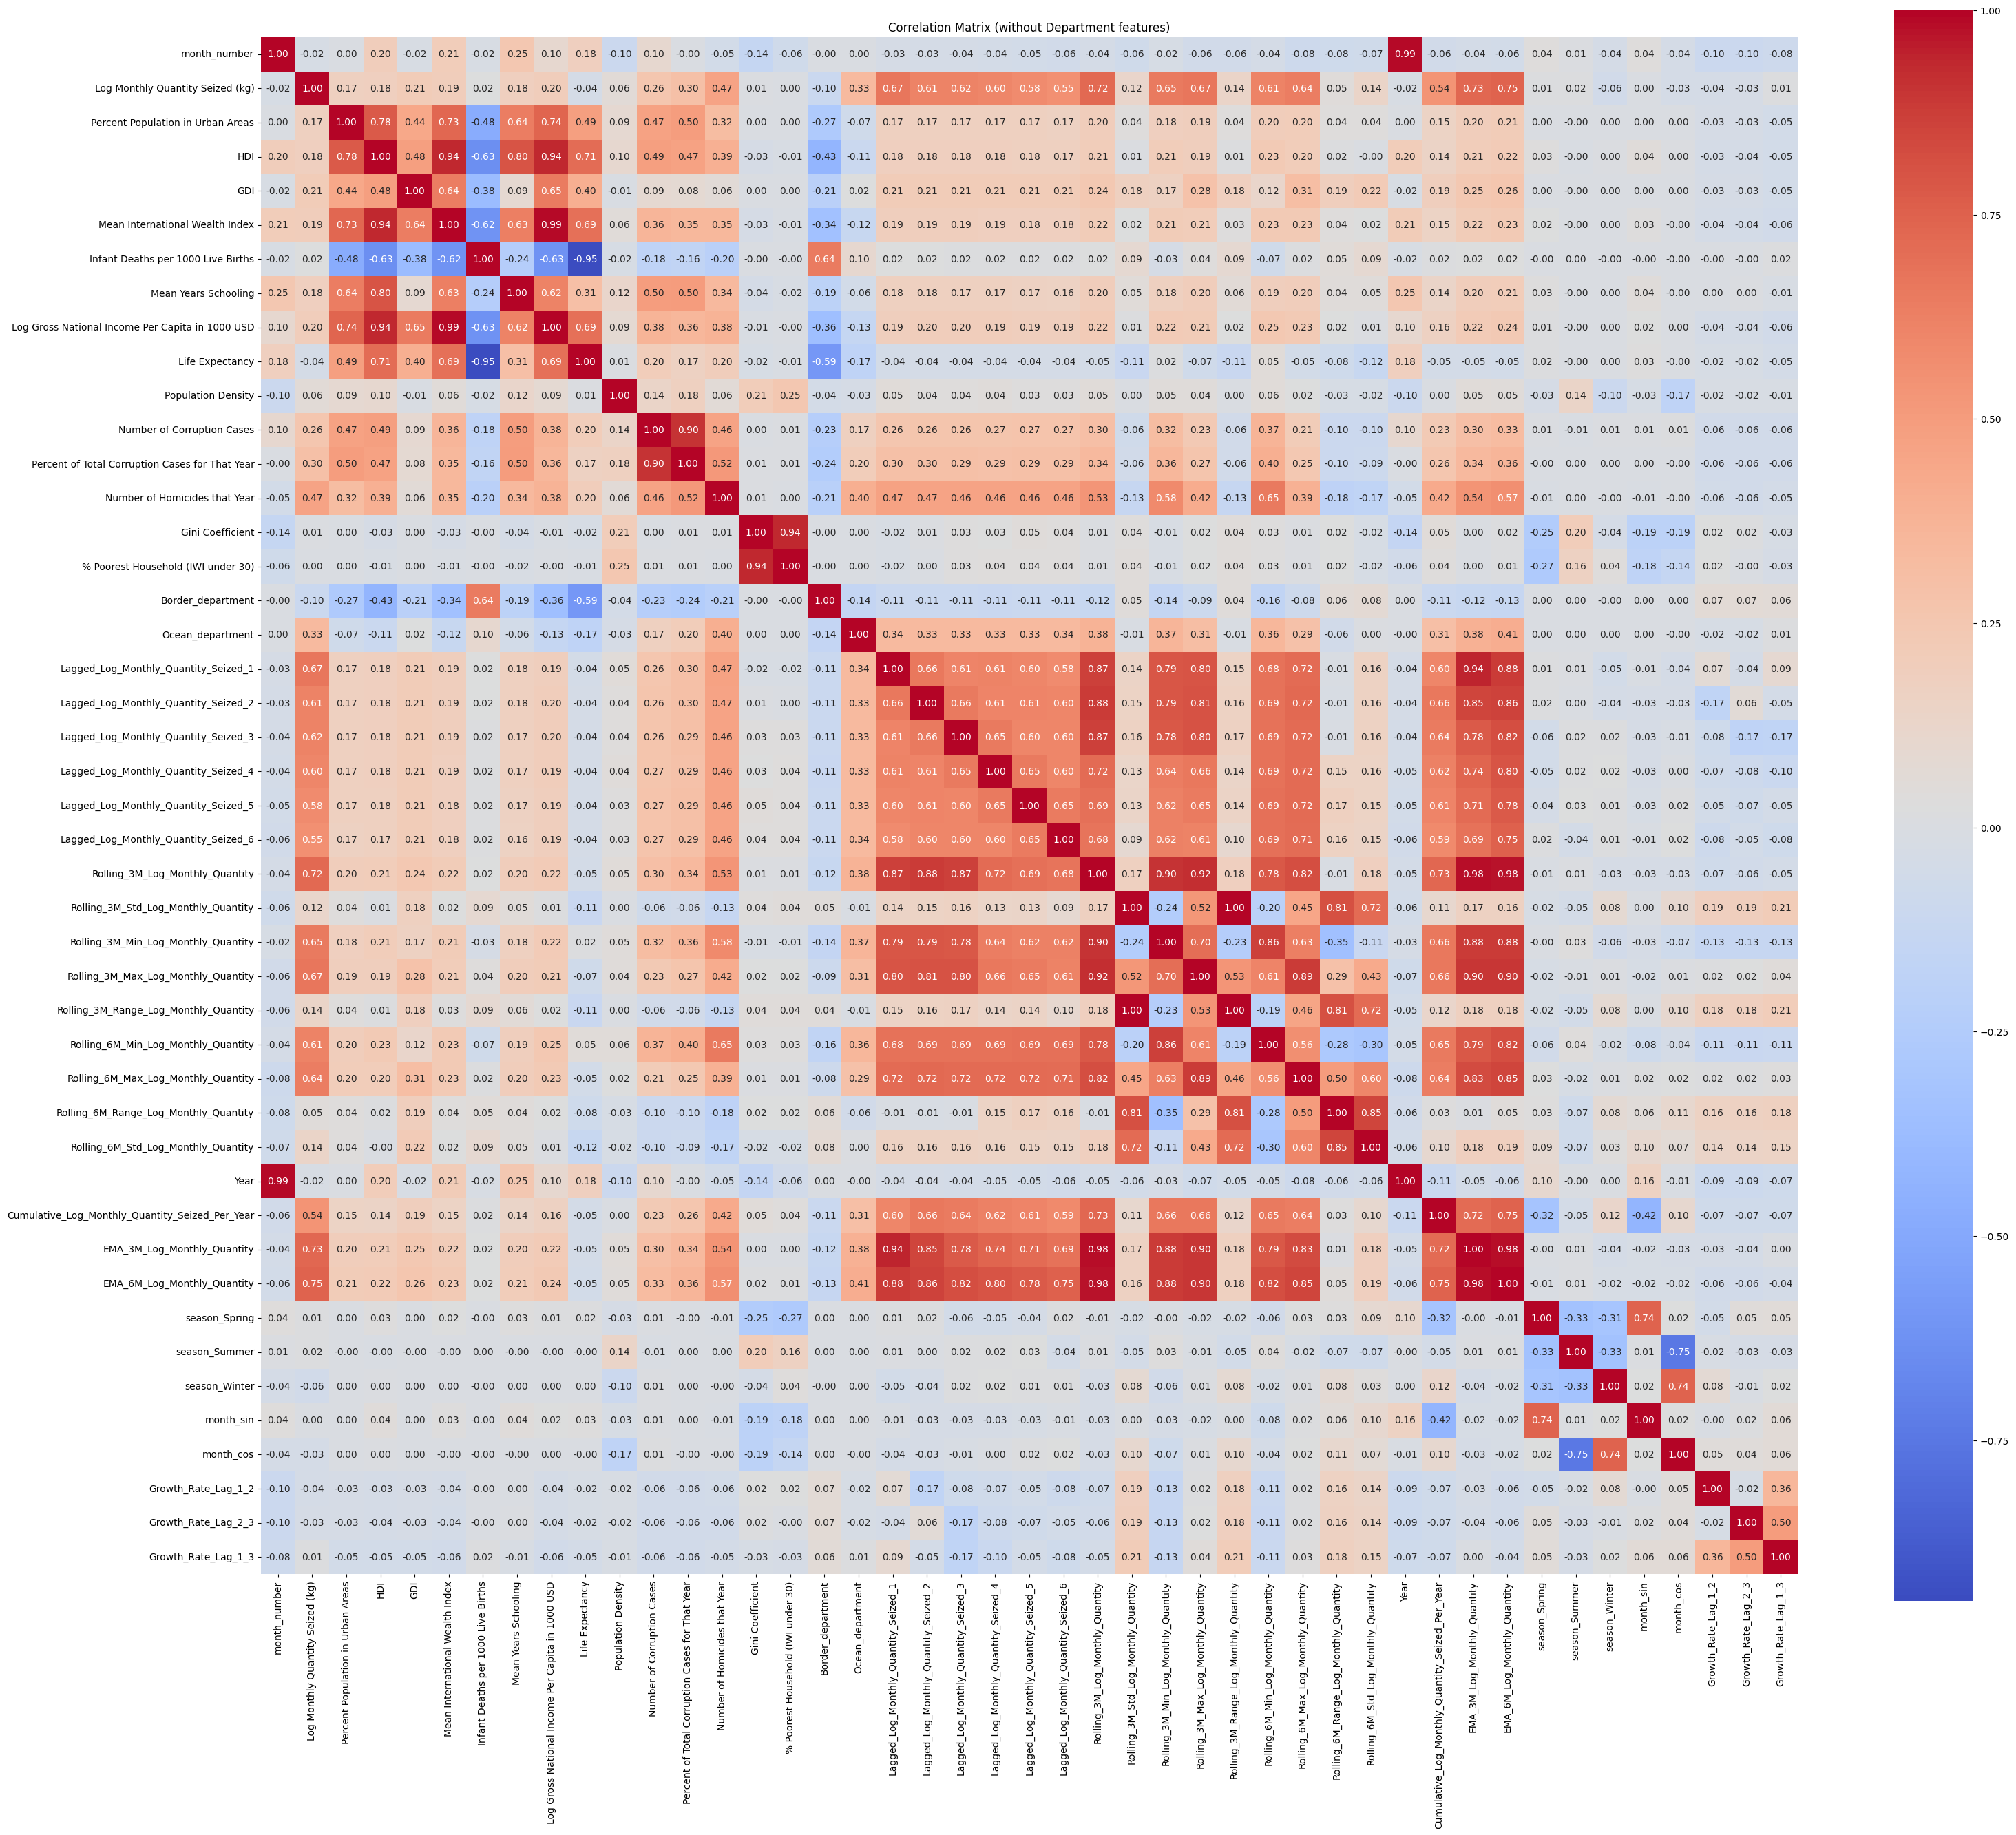

In [ ]:
#@CITATION: CODE ADAPTED FROM CHAT GPT
#without departments

filtered_train_encoded = train_encoded.loc[:, ~train_encoded.columns.str.contains('Department')]

# Compute the correlation matrix
correlation_matrix = filtered_train_encoded.corr()

# Set up the matplotlib figure
plt.figure(figsize=(36, 30))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix (without Department features)')
plt.show()

